In [208]:
# ============================================================
# Q1 (Part 1): Estimate weekly fan vote counts for each contestant
# Notes:
# - Use ABC with dynamic Dirichlet priors to infer weekly fan vote share p_{i,t}
# - Enforce elimination rules (Percent/Rank) to obtain posterior distribution and uncertainty
# - Convert shares to votes using an assumed weekly total vote pool
# ============================================================

import re
import json
import hashlib
from typing import Dict, List, Tuple, Set, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [209]:
# -----------------------------
# 0) 全局配置：随机种子 + 科研风格绘图
# -----------------------------
np.random.seed(42)

# 尽量使用“scienceplots”风格（若环境没有安装则自动跳过）
try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
except Exception:
    # 如果没有 scienceplots，则手动设置一个简洁的科研风格
    plt.rcParams.update({
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "lines.linewidth": 1.6,
    })


In [210]:

# ============================================================
# 1) 读取数据 & 基础检查
# ============================================================
file_path = "2026_MCM_Problem_C_Data.csv"  # 按需修改为你的路径
df_raw = pd.read_csv(file_path, na_values=["N/A", "NA", "-", ""])

display("[Step 1] 数据读取完成")
display("Shape:", df_raw.shape)
display("Columns:", df_raw.columns.tolist())



'[Step 1] 数据读取完成'

'Shape:'

(421, 53)

'Columns:'

['celebrity_name',
 'ballroom_partner',
 'celebrity_industry',
 'celebrity_homestate',
 'celebrity_homecountry/region',
 'celebrity_age_during_season',
 'season',
 'results',
 'placement',
 'week1_judge1_score',
 'week1_judge2_score',
 'week1_judge3_score',
 'week1_judge4_score',
 'week2_judge1_score',
 'week2_judge2_score',
 'week2_judge3_score',
 'week2_judge4_score',
 'week3_judge1_score',
 'week3_judge2_score',
 'week3_judge3_score',
 'week3_judge4_score',
 'week4_judge1_score',
 'week4_judge2_score',
 'week4_judge3_score',
 'week4_judge4_score',
 'week5_judge1_score',
 'week5_judge2_score',
 'week5_judge3_score',
 'week5_judge4_score',
 'week6_judge1_score',
 'week6_judge2_score',
 'week6_judge3_score',
 'week6_judge4_score',
 'week7_judge1_score',
 'week7_judge2_score',
 'week7_judge3_score',
 'week7_judge4_score',
 'week8_judge1_score',
 'week8_judge2_score',
 'week8_judge3_score',
 'week8_judge4_score',
 'week9_judge1_score',
 'week9_judge2_score',
 'week9_judge3_score',
 'week

In [211]:
display("[Step 1] 前5行预览：")
display(df_raw.head())


'[Step 1] 前5行预览：'

,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,week1_judge1_score,...,week9_judge3_score,week9_judge4_score,week10_judge1_score,week10_judge2_score,week10_judge3_score,week10_judge4_score,week11_judge1_score,week11_judge2_score,week11_judge3_score,week11_judge4_score
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,1,Eliminated Week 4,4,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [212]:
# 评分字段列（weekX_judgeY_score）
score_cols = [c for c in df_raw.columns if re.match(r"week\d+_judge\d+_score", c)]
display("[Step 1] 评分字段数量:", len(score_cols))
display("评分字段示例:", score_cols[:6], " ...")


'[Step 1] 评分字段数量:'

44

'评分字段示例:'

['week1_judge1_score',
 'week1_judge2_score',
 'week1_judge3_score',
 'week1_judge4_score',
 'week2_judge1_score',
 'week2_judge2_score']

' ...'

In [213]:
# 赛季范围
display("[Step 1] 赛季统计：")
display("season min/max:", df_raw["season"].min(), df_raw["season"].max(), "nunique:", df_raw["season"].nunique())


'[Step 1] 赛季统计：'

'season min/max:'

1

34

'nunique:'

34

In [214]:
# ============================================================
# 2) 生成每周评委“总分/均分/评委数”字段（按行：一个选手一季）
# ============================================================
df = df_raw.copy()

for w in range(1, 12):
    cols_w = [c for c in score_cols if c.startswith(f"week{w}_")]
    # 当周总分：跳过缺失值求和
    df[f"week{w}_judge_total"] = df[cols_w].sum(axis=1, skipna=True)
    # 当周评委数：非缺失的评委打分数
    df[f"week{w}_judge_n"] = df[cols_w].notna().sum(axis=1)
    # 当周均分：总分 / 评委数（评委数为0则置为缺失）
    df[f"week{w}_judge_mean"] = df[f"week{w}_judge_total"] / df[f"week{w}_judge_n"].replace(0, np.nan)

print("\n[Step 2] 已生成 week1~week11 的 judge_total/judge_mean/judge_n")
display(df[[f"week1_judge_total", f"week1_judge_mean", f"week1_judge_n"]].head())



[Step 2] 已生成 week1~week11 的 judge_total/judge_mean/judge_n


,week1_judge_total,week1_judge_mean,week1_judge_n
0,20.0,6.666667,3
1,13.0,4.333333,3
2,18.0,6.000000,3
3,20.0,6.666667,3
4,20.0,6.666667,3


In [215]:
# ============================================================
# 3) 推断每位选手“最后一次仍在赛的周次 last_active_week”
#    规则：当周总分 > 0 视为该周仍参赛；淘汰后数据按题意通常为 0
# ============================================================
tot_cols = [f"week{w}_judge_total" for w in range(1, 12)]

def compute_last_active_week(row):
    active_weeks = [w for w in range(1, 12) if row[f"week{w}_judge_total"] > 0]
    return max(active_weeks) if active_weeks else 0

df["last_active_week"] = df.apply(compute_last_active_week, axis=1)

# 每个赛季实际周数：该赛季所有选手的 last_active_week 最大值
season_weeks = df.groupby("season")["last_active_week"].max().to_dict()

print("\n[Step 3] last_active_week 分布：")
display(df["last_active_week"].describe())

print("\n[Step 3] 每赛季周数（前10个赛季）：")
for s in sorted(list(season_weeks.keys()))[:10]:
    print(f"Season {s}: {season_weeks[s]} weeks")

# 诊断：检查 Season 34 是否有第 11 周的数据
print("\n[诊断] 检查 Season 34 的周数据：")
season_34 = df[df["season"] == 34].copy()
if len(season_34) > 0:
    print(f"Season 34 共有 {len(season_34)} 位选手")
    for w in range(1, 12):
        col = f"week{w}_judge_total"
        if col in season_34.columns:
            non_zero = (season_34[col] > 0).sum()
            print(f"  Week {w}: {non_zero} 位选手有非零分数 (共 {len(season_34)} 位)")
    print(f"\nSeason 34 的 last_active_week 最大值: {season_34['last_active_week'].max()}")
    print(f"Season 34 的 last_active_week 分布:")
    print(season_34['last_active_week'].value_counts().sort_index())
    print(f"\nSeason 34 在 season_weeks 中的值: {season_weeks.get(34, 'NOT FOUND')}")
    if season_weeks.get(34, 0) != season_34['last_active_week'].max():
        print(f"⚠️  警告：season_weeks[34] = {season_weeks.get(34, 0)}，但实际最大值应为 {season_34['last_active_week'].max()}")
        # 修复 season_weeks[34]
        season_weeks[34] = int(season_34['last_active_week'].max())
        print(f"✅ 已修复：season_weeks[34] = {season_weeks[34]}")


[Step 3] last_active_week 分布：


count    421.000000
mean       6.596200
std        3.132531
min        1.000000
25%        4.000000
50%        7.000000
75%       10.000000
max       11.000000
Name: last_active_week, dtype: float64


[Step 3] 每赛季周数（前10个赛季）：
Season 1: 6 weeks
Season 2: 8 weeks
Season 3: 10 weeks
Season 4: 10 weeks
Season 5: 10 weeks
Season 6: 10 weeks
Season 7: 10 weeks
Season 8: 11 weeks
Season 9: 10 weeks
Season 10: 10 weeks

[诊断] 检查 Season 34 的周数据：
Season 34 共有 14 位选手
  Week 1: 14 位选手有非零分数 (共 14 位)
  Week 2: 14 位选手有非零分数 (共 14 位)
  Week 3: 12 位选手有非零分数 (共 14 位)
  Week 4: 11 位选手有非零分数 (共 14 位)
  Week 5: 10 位选手有非零分数 (共 14 位)
  Week 6: 10 位选手有非零分数 (共 14 位)
  Week 7: 9 位选手有非零分数 (共 14 位)
  Week 8: 8 位选手有非零分数 (共 14 位)
  Week 9: 7 位选手有非零分数 (共 14 位)
  Week 10: 6 位选手有非零分数 (共 14 位)
  Week 11: 5 位选手有非零分数 (共 14 位)

Season 34 的 last_active_week 最大值: 11
Season 34 的 last_active_week 分布:
last_active_week
2     2
3     1
4     1
6     1
7     1
8     1
9     1
10    1
11    5
Name: count, dtype: int64

Season 34 在 season_weeks 中的值: 11


In [216]:
# ============================================================
# 4) 宽表 -> 长表：每行 = season-week-celebrity
# ============================================================
keep_cols = [
    "celebrity_name", "ballroom_partner",
    "celebrity_industry", "celebrity_homestate",
    "celebrity_homecountry/region", "celebrity_age_during_season",
    "season", "results", "placement",
    "last_active_week"
]
long_blocks = []
for w in range(1, 12):
    tmp = df[keep_cols].copy()
    tmp["week"] = w
    tmp["judge_total"] = df[f"week{w}_judge_total"].values
    tmp["judge_mean"] = df[f"week{w}_judge_mean"].values
    tmp["judge_n"] = df[f"week{w}_judge_n"].values
    long_blocks.append(tmp)

long_df = pd.concat(long_blocks, ignore_index=True)

# 标注赛季周数、是否属于该赛季范围、是否当周仍在赛
long_df["season_weeks"] = long_df["season"].map(season_weeks)
long_df["is_week_in_season"] = long_df["week"] <= long_df["season_weeks"]
long_df["is_active"] = long_df["is_week_in_season"] & (long_df["judge_total"] > 0)

print("\n[Step 4] 长表生成完成")
print("Shape:", long_df.shape)
print("Active ratio:", long_df["is_active"].mean())
print("\n[Step 4] 长表前5行：")
display(long_df.head())


[Step 4] 长表生成完成
Shape: (4631, 17)
Active ratio: 0.5996545022673289

[Step 4] 长表前5行：


,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,last_active_week,week,judge_total,judge_mean,judge_n,season_weeks,is_week_in_season,is_active
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,6,1,20.0,6.666667,3,6,True,True
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,6,1,13.0,4.333333,3,6,True,True
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,3,1,18.0,6.000000,3,6,True,True
3,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,1,Eliminated Week 4,4,4,1,20.0,6.666667,3,6,True,True
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,5,1,20.0,6.666667,3,6,True,True


In [217]:
# ============================================================
# 5) 构造动态特征（仅依赖“到本周为止”的信息）
#    - 评分趋势：上一周分数、分数增量
#    - 累计水平：累计均值/累计总分
#    - 近3周滚动均值/波动
#    - 当周相对位置：当周评分排名（同一 season-week 内）
# ============================================================
long_df = long_df.sort_values(["season", "celebrity_name", "week"]).reset_index(drop=True)

# 上一周总分与变化量
long_df["judge_total_prev"] = long_df.groupby(["season", "celebrity_name"])["judge_total"].shift(1)
long_df["judge_total_delta"] = long_df["judge_total"] - long_df["judge_total_prev"]

# 累计均值/累计总分（expanding 基于到本周）
long_df["cum_judge_mean"] = (
    long_df.groupby(["season", "celebrity_name"])["judge_total"]
    .expanding().mean().reset_index(level=[0, 1], drop=True)
)
long_df["cum_judge_sum"] = long_df.groupby(["season", "celebrity_name"])["judge_total"].cumsum()

# 近3周滚动均值/波动
long_df["roll3_mean"] = (
    long_df.groupby(["season", "celebrity_name"])["judge_total"]
    .rolling(3, min_periods=1).mean().reset_index(level=[0, 1], drop=True)
)
long_df["roll3_std"] = (
    long_df.groupby(["season", "celebrity_name"])["judge_total"]
    .rolling(3, min_periods=1).std().reset_index(level=[0, 1], drop=True)
)

# 当周评分排名（分高排名小）
long_df["judge_rank"] = long_df.groupby(["season", "week"])["judge_total"].rank(ascending=False, method="average")

# 当周评分的标准化（用于后续“人气分数”融合）
long_df["judge_total_week_mean"] = long_df.groupby(["season", "week"])["judge_total"].transform("mean")
long_df["judge_total_week_std"] = long_df.groupby(["season", "week"])["judge_total"].transform("std").replace(0, np.nan)
long_df["judge_total_week_z"] = (long_df["judge_total"] - long_df["judge_total_week_mean"]) / long_df["judge_total_week_std"]

print("\n[Step 5] 特征构造完成，示例列：")
display(long_df[[
    "season", "week", "celebrity_name",
    "judge_total", "judge_total_prev", "judge_total_delta",
    "cum_judge_mean", "roll3_mean", "roll3_std",
    "judge_rank", "judge_total_week_z"
]].head(10))



[Step 5] 特征构造完成，示例列：


,season,week,celebrity_name,judge_total,judge_total_prev,judge_total_delta,cum_judge_mean,roll3_mean,roll3_std,judge_rank,judge_total_week_z
0,1,1,Evander Holyfield,18.0,NaN,NaN,18.000000,18.000000,NaN,4.5,-0.061406
1,1,2,Evander Holyfield,14.0,18.0,-4.0,16.000000,16.000000,2.828427,6.0,-1.387023
2,1,3,Evander Holyfield,13.0,14.0,-1.0,15.000000,15.000000,2.645751,5.0,-0.479632
3,1,4,Evander Holyfield,0.0,13.0,-13.0,11.250000,9.000000,7.810250,5.5,-1.267838
4,1,5,Evander Holyfield,0.0,0.0,0.0,9.000000,4.333333,7.505553,5.0,-0.907186
5,1,6,Evander Holyfield,0.0,0.0,0.0,7.500000,0.000000,0.000000,4.5,-0.645456
6,1,7,Evander Holyfield,0.0,0.0,0.0,6.428571,0.000000,0.000000,3.5,NaN
7,1,8,Evander Holyfield,0.0,0.0,0.0,5.625000,0.000000,0.000000,3.5,NaN
8,1,9,Evander Holyfield,0.0,0.0,0.0,5.000000,0.000000,0.000000,3.5,NaN
9,1,10,Evander Holyfield,0.0,0.0,0.0,4.500000,0.000000,0.000000,3.5,NaN


In [218]:
long_df[[
    "season", "week", "celebrity_name",
    "judge_total", "judge_total_prev", "judge_total_delta",
    "cum_judge_mean", "roll3_mean", "roll3_std",
    "judge_rank", "judge_total_week_z"
]]

,season,week,celebrity_name,judge_total,judge_total_prev,judge_total_delta,cum_judge_mean,roll3_mean,roll3_std,judge_rank,judge_total_week_z
0,1,1,Evander Holyfield,18.0,NaN,NaN,18.000000,18.000000,NaN,4.5,-0.061406
1,1,2,Evander Holyfield,14.0,18.0,-4.0,16.000000,16.000000,2.828427,6.0,-1.387023
2,1,3,Evander Holyfield,13.0,14.0,-1.0,15.000000,15.000000,2.645751,5.0,-0.479632
3,1,4,Evander Holyfield,0.0,13.0,-13.0,11.250000,9.000000,7.810250,5.5,-1.267838
4,1,5,Evander Holyfield,0.0,0.0,0.0,9.000000,4.333333,7.505553,5.0,-0.907186
...,...,...,...,...,...,...,...,...,...,...,...
4626,34,7,Whitney Leavitt,42.0,39.0,3.0,28.571429,38.000000,4.582576,2.0,0.976891
4627,34,8,Whitney Leavitt,39.5,42.0,-2.5,29.937500,40.166667,1.607275,1.0,0.926273
4628,34,9,Whitney Leavitt,42.0,39.5,2.5,31.277778,41.166667,1.443376,2.0,1.120428
4629,34,10,Whitney Leavitt,29.0,42.0,-13.0,31.050000,36.833333,6.898067,2.5,1.134870


In [219]:
# ============================================================
# 6) ABC model: utilities (Rank/Percent rules + sampling)
# ============================================================

def extract_week_columns(columns: List[str]) -> Dict[int, List[str]]:
    # Parse weekX_judgeY_score columns
    pattern = re.compile(r"week(\d+)_judge\d+_score")
    week_cols: Dict[int, List[str]] = {}
    for col in columns:
        m = pattern.match(col)
        if m:
            week = int(m.group(1))
            week_cols.setdefault(week, []).append(col)
    return dict(sorted(week_cols.items(), key=lambda x: x[0]))


def scheme_for_season(season: int) -> str:
    # Rule type: Rank or Percent
    if season in (1, 2) or season >= 28:
        return "Rank"
    return "Percent"


def stable_seed(base_seed: int, season: int, week: int, tag: str) -> int:
    # Stable 32-bit seed to avoid Python hash randomness
    payload = f"{base_seed}|{season}|{week}|{tag}".encode("utf-8")
    digest = hashlib.blake2b(payload, digest_size=4).digest()
    return int.from_bytes(digest, "little")


def build_week_tasks(df_in: pd.DataFrame, week_cols: Dict[int, List[str]]) -> List[Dict[str, Any]]:
    # Build per-season, per-week inference tasks
    weeks = sorted(week_cols.keys())
    tasks: List[Dict[str, Any]] = []

    for season, sdf in df_in.groupby("season"):
        sdf = sdf.reset_index(drop=True)
        names_all = sdf["celebrity_name"].astype(str).tolist()

        active_by_week: Dict[int, List[str]] = {}
        for week in weeks:
            total_col = f"week{week}_judge_total"
            totals = sdf[total_col].fillna(0.0).astype(float).to_numpy()
            active_mask = totals > 0.0
            active_names = [names_all[i] for i in range(len(names_all)) if active_mask[i]]
            active_by_week[week] = active_names

        for i, week in enumerate(weeks[:-1]):
            next_week = weeks[i + 1]
            if len(active_by_week[next_week]) == 0:
                continue
            active = active_by_week[week]
            if len(active) == 0:
                continue
            elim = set(active) - set(active_by_week[next_week])

            total_col = f"week{week}_judge_total"
            totals_series = sdf.set_index("celebrity_name")[total_col].fillna(0.0).astype(float)
            judge_totals = {nm: float(totals_series.get(nm, 0.0)) for nm in active}

            tasks.append({
                "season": int(season),
                "week": int(week),
                "names": active,
                "judge_totals": judge_totals,
                "elim_set": elim,
                "scheme": scheme_for_season(int(season)),
            })

    tasks.sort(key=lambda x: (x["season"], x["week"]))
    return tasks


def rank_average_desc(x: np.ndarray) -> np.ndarray:
    # High score gets rank 1, ties use average rank
    return pd.Series(x).rank(ascending=False, method="average").to_numpy()


def elim_percent(names: List[str], J: Dict[str, float], p: np.ndarray, k: int) -> Set[str]:
    # Percent: C_i = J_i/sumJ + p_i, eliminate smallest k
    if k <= 0:
        return set()
    sumJ = sum(J[n] for n in names) or 1.0
    C = [(names[i], J[names[i]] / sumJ + float(p[i])) for i in range(len(names))]
    C.sort(key=lambda t: (t[1], t[0]))
    return {n for n, _ in C[:k]}


def elim_rank(names: List[str], J: Dict[str, float], p: np.ndarray, k: int) -> Set[str]:
    # Rank: R_i = rank(J_i) + rank(p_i), eliminate largest k
    if k <= 0:
        return set()
    j = np.array([J[n] for n in names], dtype=float)
    rsum = rank_average_desc(j) + rank_average_desc(p)
    # Sort by rsum descending, name ascending (stable tie-break)
    pairs = sorted(zip(names, rsum), key=lambda t: (-t[1], t[0]))
    return {n for n, _ in pairs[:k]}


def predict_elim(names, J, p, k, scheme) -> Set[str]:
    return elim_percent(names, J, p, k) if scheme == "Percent" else elim_rank(names, J, p, k)


def margin_percent(names: List[str], J: Dict[str, float], p: np.ndarray, k: int) -> float:
    # Percent margin: C_(k+1) - C_(k)
    n = len(names)
    if k <= 0 or k >= n:
        return np.nan
    sumJ = sum(J[n] for n in names) or 1.0
    c_vals = np.array([J[nm] / sumJ + float(p[i]) for i, nm in enumerate(names)])
    c_sorted = np.sort(c_vals)
    return float(c_sorted[k] - c_sorted[k - 1])


def margin_rank(names: List[str], J: Dict[str, float], p: np.ndarray, k: int) -> float:
    # Rank margin: R_(k) - R_(k+1)
    n = len(names)
    if k <= 0 or k >= n:
        return np.nan
    j = np.array([J[n] for n in names], dtype=float)
    rsum = rank_average_desc(j) + rank_average_desc(p)
    r_sorted = np.sort(rsum)[::-1]
    return float(r_sorted[k - 1] - r_sorted[k])


def predict_elim_and_margin(names, J, p, k, scheme) -> Tuple[Set[str], float]:
    if scheme == "Percent":
        return predict_elim(names, J, p, k, scheme), margin_percent(names, J, p, k)
    return predict_elim(names, J, p, k, scheme), margin_rank(names, J, p, k)


def abc_week(
    names: List[str],
    judge_totals: Dict[str, float],
    elim_set: Set[str],
    scheme: str,
    prev_p: Optional[Dict[str, float]] = None,
    alpha0: float = 5.0,
    kappa: float = 40.0,
    n_accept: int = 500,
    draw_max: int = 50000,
    seed: int = 1234,
) -> Tuple[np.ndarray, float, str, np.ndarray]:
    # Returns: p_mean, accept_rate, status, samples
    rng = np.random.default_rng(seed)
    n = len(names)
    k = len(elim_set)

    # Prior: alpha = alpha0 + kappa * prev_vec
    alpha = np.full(n, alpha0, dtype=float)
    if isinstance(prev_p, dict):
        v = np.array([float(prev_p.get(nm, 0.0)) for nm in names], dtype=float)
        if v.sum() > 0:
            v = v / v.sum()
            alpha = alpha0 + kappa * v

    def run(alpha_vec: np.ndarray):
        acc = []
        draws = 0
        while draws < draw_max and len(acc) < n_accept:
            p = rng.dirichlet(np.maximum(alpha_vec, 1e-6))
            if predict_elim(names, judge_totals, p, k, scheme) == elim_set:
                acc.append(p)
            draws += 1
        samples = np.vstack(acc) if len(acc) else np.zeros((0, n))
        return samples, len(acc), draws

    samples, accepted, draws = run(alpha)
    status = "ok"

    if accepted == 0:
        status = "fallback_uniform"
        samples, accepted, draws = run(np.ones(n, dtype=float))

    if accepted == 0:
        return np.full(n, np.nan), 0.0, "failed", np.zeros((0, n))

    p_mean = samples.mean(axis=0)
    accept_rate = accepted / draws if draws > 0 else 0.0
    return p_mean, accept_rate, status, samples


In [220]:
# ============================================================
# 7) Run ABC: estimate weekly fan vote share (p_{i,t})
#    修复点1：p_map 不再等于 p_mean，而是用 accepted samples 近似 MAP（mode）
# ============================================================

from typing import List, Dict, Any, Optional, Tuple
import numpy as np
import pandas as pd

ABC_ALPHA0 = 5.0
ABC_KAPPA = 40.0
ABC_N_ACCEPT = 500
ABC_DRAW_MAX = 50000
ABC_T = 1.0
ABC_SEED = 1234


# -----------------------------
# 工具函数：投影到 simplex（非负且和为1）
# -----------------------------
def project_to_simplex(p: np.ndarray, eps: float = 1e-15) -> np.ndarray:
    """把向量投影为概率向量：p_i >= 0, sum p_i = 1。"""
    p = np.asarray(p, dtype=float).copy()
    p[~np.isfinite(p)] = 0.0
    p[p < 0] = 0.0
    s = p.sum()
    if s <= 0:
        # 如果全0或异常，返回均匀分布
        return np.full_like(p, 1.0 / len(p), dtype=float)
    p = p / s
    # 避免出现精确0导致 log/密度计算炸
    p = np.maximum(p, eps)
    p = p / p.sum()
    return p


# -----------------------------
# 近似 MAP：kNN 伪密度最大点（推荐）
# -----------------------------
def approx_map_knn(samples: np.ndarray, k: int = 10, eps: float = 1e-15) -> np.ndarray:
    """
    用k近邻距离构造伪密度：density ~ 1 / r_k^d，取密度最大的样本作为 MAP proxy。
    - samples: (m, n) 每行是一个 accepted p 向量
    - k: 近邻数，经验上 5~20 之间都可；默认10
    """
    X = np.asarray(samples, dtype=float)
    m, n = X.shape
    if m == 1:
        return project_to_simplex(X[0], eps=eps)

    # k不能超过 m-1
    k = int(max(1, min(k, m - 1)))

    # 计算两两距离（m<=500 时可接受）
    # 用欧氏距离即可（简单、稳定）；想更“信息论”可换成 JS divergence，但代价更高
    diff = X[:, None, :] - X[None, :, :]
    D = np.sqrt(np.sum(diff * diff, axis=2))  # (m, m)
    np.fill_diagonal(D, np.inf)

    # 每个点到第k近邻的距离 r_k
    rk = np.partition(D, kth=k - 1, axis=1)[:, k - 1]  # (m,)

    # 伪log密度：-d*log(rk)，d取维度n-1（simplex内在维度）
    d = max(1, n - 1)
    score = -d * np.log(rk + 1e-300)  # 防止log(0)

    idx = int(np.argmax(score))
    return project_to_simplex(X[idx], eps=eps)


# -----------------------------
# 近似 MAP：稳健回退（median）
# -----------------------------
def approx_map_median(samples: np.ndarray, eps: float = 1e-15) -> np.ndarray:
    """逐维中位数后再投影到simplex，作为稳健代表点。"""
    p = np.median(samples, axis=0)
    return project_to_simplex(p, eps=eps)


def estimate_p_map(samples: np.ndarray,
                   method: str = "knn",
                   knn_k: int = 10,
                   eps: float = 1e-15) -> np.ndarray:
    """
    统一入口：从 accepted samples 估计 p_map（MAP proxy）。
    method:
      - "knn": kNN 伪密度最大点（更像 mode）
      - "median": 稳健代表点
    """
    X = np.asarray(samples, dtype=float)
    if X.ndim != 2 or X.shape[0] == 0:
        raise ValueError("samples must be a non-empty 2D array")

    # 样本太少时，knn不稳，直接median
    if X.shape[0] < 30:
        return approx_map_median(X, eps=eps)

    if method == "knn":
        return approx_map_knn(X, k=knn_k, eps=eps)
    elif method == "median":
        return approx_map_median(X, eps=eps)
    else:
        raise ValueError(f"Unknown method: {method}")


# ============================================================
# 下面是你原来的主循环（仅在 p_map 计算处替换）
# 依赖你已有的：extract_week_columns, build_week_tasks, stable_seed, abc_week, predict_elim_and_margin
# ============================================================

week_cols = extract_week_columns(df.columns.tolist())
if not week_cols:
    raise ValueError("No weekX_judgeY_score columns found.")

tasks = build_week_tasks(df, week_cols)

est_rows: List[Dict[str, Any]] = []
summary_rows: List[Dict[str, Any]] = []
prev_p_by_season: Dict[int, Optional[Dict[str, float]]] = {}

for task in tasks:
    season = task["season"]
    week = task["week"]
    names = task["names"]
    judge_totals = task["judge_totals"]
    elim_set = task["elim_set"]
    scheme = task["scheme"]
    n = len(names)

    local_seed = stable_seed(ABC_SEED, season, week, "abc")

    prev_p = prev_p_by_season.get(season, None)
    have_prev = isinstance(prev_p, dict)
    prior_source = "smoothed_from_prev" if have_prev else "initial"

    p_mean, accept_rate, status, samples = abc_week(
        names=names,
        judge_totals=judge_totals,
        elim_set=elim_set,
        scheme=scheme,
        prev_p=prev_p,
        alpha0=ABC_ALPHA0,
        kappa=ABC_KAPPA,
        n_accept=ABC_N_ACCEPT,
        draw_max=ABC_DRAW_MAX,
        seed=local_seed,
    )

    accepted = samples.shape[0]

    if accepted == 0:
        p_std = np.full(n, np.nan)
        p_q05 = np.full(n, np.nan)
        p_q10 = np.full(n, np.nan)
        p_q50 = np.full(n, np.nan)
        p_q90 = np.full(n, np.nan)
        p_q95 = np.full(n, np.nan)
        p_map = np.full(n, np.nan)
        mean_entropy = np.nan
    else:
        # -----------------------------
        # 样本统计
        # -----------------------------
        p_std = samples.std(axis=0)
        p_q05 = np.quantile(samples, 0.05, axis=0)
        p_q10 = np.quantile(samples, 0.10, axis=0)
        p_q50 = np.quantile(samples, 0.50, axis=0)
        p_q90 = np.quantile(samples, 0.90, axis=0)
        p_q95 = np.quantile(samples, 0.95, axis=0)

        # -----------------------------
        # ✅ 修复点1：用 accepted samples 近似 MAP（不再等于 p_mean）
        # 推荐 knn；样本少会自动回退 median
        # -----------------------------
        p_map = estimate_p_map(samples, method="knn", knn_k=10, eps=1e-15)

        # entropy（你原来的写法保留）
        eps = 1e-12
        mean_entropy = float((-samples * np.log(samples + eps)).sum(axis=1).mean())

    for i, nm in enumerate(names):
        p_m = float(p_mean[i]) if np.isfinite(p_mean[i]) else np.nan
        p_s = float(p_std[i]) if np.isfinite(p_std[i]) else np.nan
        p_05 = float(p_q05[i]) if np.isfinite(p_q05[i]) else np.nan
        p_10 = float(p_q10[i]) if np.isfinite(p_q10[i]) else np.nan
        p_50 = float(p_q50[i]) if np.isfinite(p_q50[i]) else np.nan
        p_90 = float(p_q90[i]) if np.isfinite(p_q90[i]) else np.nan
        p_95 = float(p_q95[i]) if np.isfinite(p_q95[i]) else np.nan
        p_mp = float(p_map[i]) if np.isfinite(p_map[i]) else np.nan

        ci_w = p_95 - p_05 if np.isfinite(p_95) and np.isfinite(p_05) else np.nan
        rel_w = ci_w / p_m if np.isfinite(ci_w) and np.isfinite(p_m) and p_m > 0 else np.nan

        est_rows.append({
            "season": season,
            "week": week,
            "celebrity_name": nm,
            "p_mean": p_m,
            "p_std": p_s,
            "p_q05": p_05,
            "p_q10": p_10,
            "p_q50": p_50,
            "p_q90": p_90,
            "p_q95": p_95,
            "p_lo90": p_05,
            "p_hi90": p_95,
            "p_map": p_mp,
            "V_mean": p_m * ABC_T if np.isfinite(p_m) else np.nan,
            "V_map": p_mp * ABC_T if np.isfinite(p_mp) else np.nan,
            "accept_rate": accept_rate,
            "scheme": scheme,
            "eliminated_this_week": 1 if nm in elim_set else 0,
            "ci_width": ci_w,
            "rel_ci_width": rel_w,
            "mean_entropy": mean_entropy,
        })

    k = len(elim_set)
    consistency_mean = np.nan
    margin_mean = np.nan
    consistency_map = np.nan
    margin_map = np.nan

    if np.all(np.isfinite(p_mean)):
        pred_mean, margin_mean = predict_elim_and_margin(names, judge_totals, p_mean, k, scheme)
        consistency_mean = 1.0 if pred_mean == elim_set else 0.0

    if np.all(np.isfinite(p_map)):
        pred_map, margin_map = predict_elim_and_margin(names, judge_totals, p_map, k, scheme)
        consistency_map = 1.0 if pred_map == elim_set else 0.0

    summary_rows.append({
        "season": season,
        "week": week,
        "N_active": n,
        "scheme": scheme,
        "elim_set": ";".join(sorted(list(elim_set))),
        "accept_rate": accept_rate,
        "feasible": 1 if accepted > 0 else 0,
        "pp_consistency": np.nan,
        "pp_consistency_se": np.nan,
        "soft_eps": np.nan,
        "soft_ess": np.nan,
        "soft_draws": 0,
        "consistency_mean": consistency_mean,
        "margin_mean": margin_mean,
        "consistency_map": consistency_map,
        "margin_map": margin_map,
        "n_accept": int(accepted),
        "draws": np.nan,  # 如果你能从 abc_week 返回 draws，建议填上
        "status": status,
        "prior_source": prior_source,
    })

    if np.all(np.isfinite(p_mean)):
        prev_p_by_season[season] = {nm: float(p_mean[i]) for i, nm in enumerate(names)}
    else:
        prev_p_by_season[season] = None

est_df = pd.DataFrame(est_rows)
summary_df = pd.DataFrame(summary_rows)

week_uncertainty = (
    est_df.groupby(["season", "week"])["rel_ci_width"]
    .mean()
    .reset_index()
    .rename(columns={"rel_ci_width": "week_uncertainty"})
)
summary_df = summary_df.merge(week_uncertainty, on=["season", "week"], how="left")

corr_df = summary_df[["margin_map", "week_uncertainty"]].dropna()
pearson = float(corr_df["margin_map"].corr(corr_df["week_uncertainty"], method="pearson")) if len(corr_df) > 1 else float("nan")
spearman = float(corr_df["margin_map"].corr(corr_df["week_uncertainty"], method="spearman")) if len(corr_df) > 1 else float("nan")

global_metrics = {
    "corr_margin_uncertainty_pearson": pearson,
    "corr_margin_uncertainty_spearman": spearman,
    "n_weeks": int(len(corr_df)),
}

print()
print("[ABC] Done: est_df / summary_df ready")
print("est_df shape:", est_df.shape)
print("summary_df shape:", summary_df.shape)
print("global_metrics:", global_metrics)



[ABC] Done: est_df / summary_df ready
est_df shape: (2659, 21)
summary_df shape: (301, 21)
global_metrics: {'corr_margin_uncertainty_pearson': 0.26488765913839135, 'corr_margin_uncertainty_spearman': 0.10915621500415798, 'n_weeks': 261}


In [221]:
# ============================================================
# 8) Build main result table (compatible with downstream evaluation/plots)
# ============================================================
merge_cols = [
    "season", "week", "celebrity_name",
    "ballroom_partner", "celebrity_industry", "celebrity_homestate",
    "celebrity_homecountry/region", "celebrity_age_during_season",
    "judge_total", "judge_mean", "judge_n",
    "season_weeks", "results", "placement",
]

pred_df = est_df.merge(
    long_df[long_df["is_active"]][merge_cols],
    on=["season", "week", "celebrity_name"],
    how="left",
)

pred_df["vote_share_hat"] = pred_df["p_mean"]

BASE_TOTAL_VOTES = 1000000

def week_vote_pool(row):
    w = row["week"]
    W = row["season_weeks"]
    if W <= 1:
        return BASE_TOTAL_VOTES
    factor = 0.8 + 0.6 * (w - 1) / (W - 1)
    return BASE_TOTAL_VOTES * factor

pred_df["total_votes_hat"] = pred_df.apply(week_vote_pool, axis=1)
pred_df["votes_hat"] = pred_df["vote_share_hat"] * pred_df["total_votes_hat"]
pred_df["votes_map"] = pred_df["p_map"] * pred_df["total_votes_hat"]

for q in [5, 10, 50, 90, 95]:
    pq = f"p_q{q:02d}"
    vq = f"votes_q{q:02d}"
    if pq in pred_df.columns:
        pred_df[vq] = pred_df[pq] * pred_df["total_votes_hat"]
    else:
        pred_df[vq] = np.nan

pred_df["votes_mean"] = pred_df["votes_hat"]
pred_df["votes_std"] = pred_df["p_std"] * pred_df["total_votes_hat"]

pred_df["p_survive_next"] = np.nan

result_cols = [
    "season", "week", "celebrity_name", "ballroom_partner",
    "celebrity_industry", "celebrity_homestate", "celebrity_homecountry/region",
    "celebrity_age_during_season",
    "judge_total", "judge_mean", "judge_n",
    "p_survive_next", "vote_share_hat", "total_votes_hat", "votes_hat",
    "placement", "results",
]

result_df = pred_df[result_cols].sort_values(["season", "week", "votes_hat"], ascending=[True, True, False])

print()
print("[Step 8] Preview of result_df")
display(result_df.head(15))



[Step 8] Preview of result_df


,season,week,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,judge_total,judge_mean,judge_n,p_survive_next,vote_share_hat,total_votes_hat,votes_hat,placement,results
2,1,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,18.0,6.000000,3,NaN,0.170330,800000.0,136264.038795,5,Eliminated Week 3
1,1,1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,13.0,4.333333,3,NaN,0.168692,800000.0,134953.737989,1,1st Place
5,1,1,Trista Sutter,Louis van Amstel,TV Personality,Indiana,United States,32,18.0,6.000000,3,NaN,0.168619,800000.0,134895.077126,6,Eliminated Week 2
4,1,1,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,20.0,6.666667,3,NaN,0.167688,800000.0,134150.346467,3,3rd Place
3,1,1,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,20.0,6.666667,3,NaN,0.162370,800000.0,129896.063918,4,Eliminated Week 4
0,1,1,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,20.0,6.666667,3,NaN,0.162301,800000.0,129840.735706,2,2nd Place
8,1,2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,14.0,4.666667,3,NaN,0.203224,920000.0,186966.341228,5,Eliminated Week 3
7,1,2,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,17.0,5.666667,3,NaN,0.189001,920000.0,173881.340960,1,1st Place
10,1,2,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,21.0,7.000000,3,NaN,0.172209,920000.0,158432.708549,3,3rd Place
9,1,2,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,24.0,8.000000,3,NaN,0.160854,920000.0,147985.899616,4,Eliminated Week 4


In [222]:
# ============================================================
# 9) Write outputs
# ============================================================
result_df.to_csv("dwts_vote_estimates_part1.csv", index=False)

est_df.to_csv("fan_vote_estimates.csv", index=False)
summary_df.to_csv("weekly_summary.csv", index=False)
with open("global_metrics.json", "w", encoding="utf-8") as f:
    json.dump(global_metrics, f, ensure_ascii=False, indent=2)

print()
print("[Output] Wrote: dwts_vote_estimates_part1.csv / fan_vote_estimates.csv / weekly_summary.csv / global_metrics.json")



[Output] Wrote: dwts_vote_estimates_part1.csv / fan_vote_estimates.csv / weekly_summary.csv / global_metrics.json


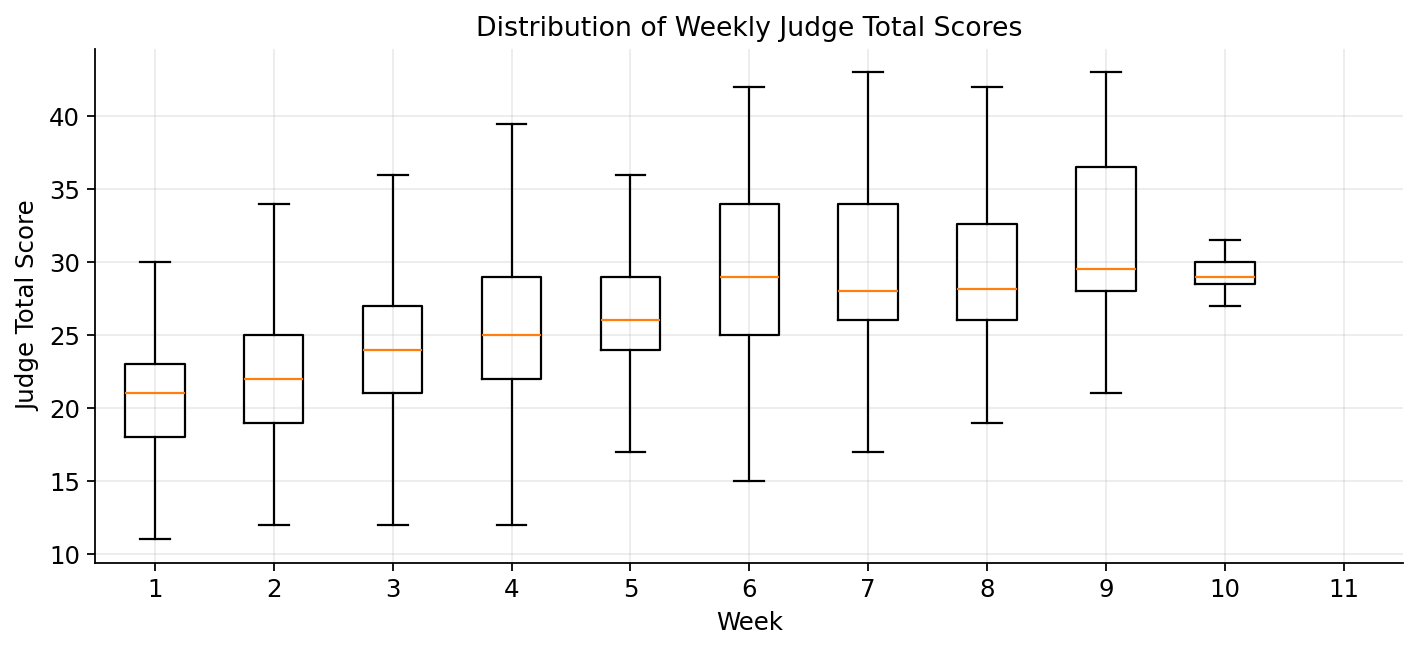

In [223]:
# ============================================================
# 12.2 评委总分在不同周次的分布（箱线图）
# ============================================================
# 仅使用 active 的评分
judge_by_week = [pred_df.loc[pred_df["week"] == w, "judge_total"].values for w in range(1, 12)]

plt.figure(figsize=(9.0, 4.2))
plt.boxplot(judge_by_week, labels=[str(w) for w in range(1, 12)], showfliers=False)
plt.title("Distribution of Weekly Judge Total Scores")
plt.xlabel("Week")
plt.ylabel("Judge Total Score")
plt.tight_layout()
plt.show()


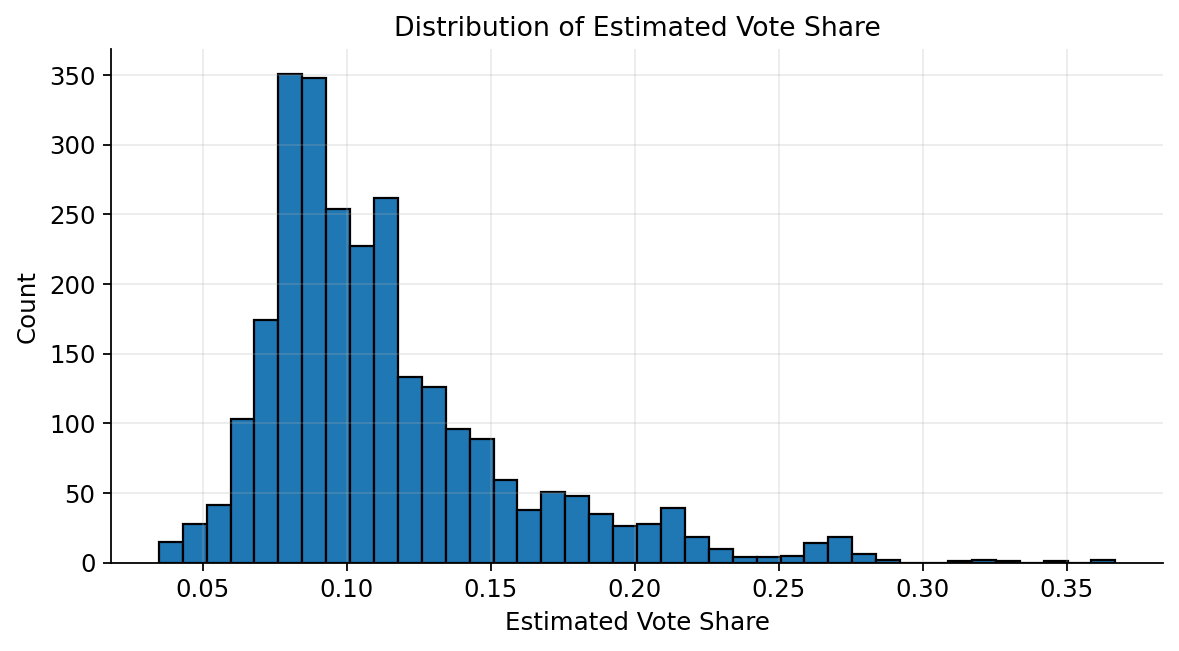

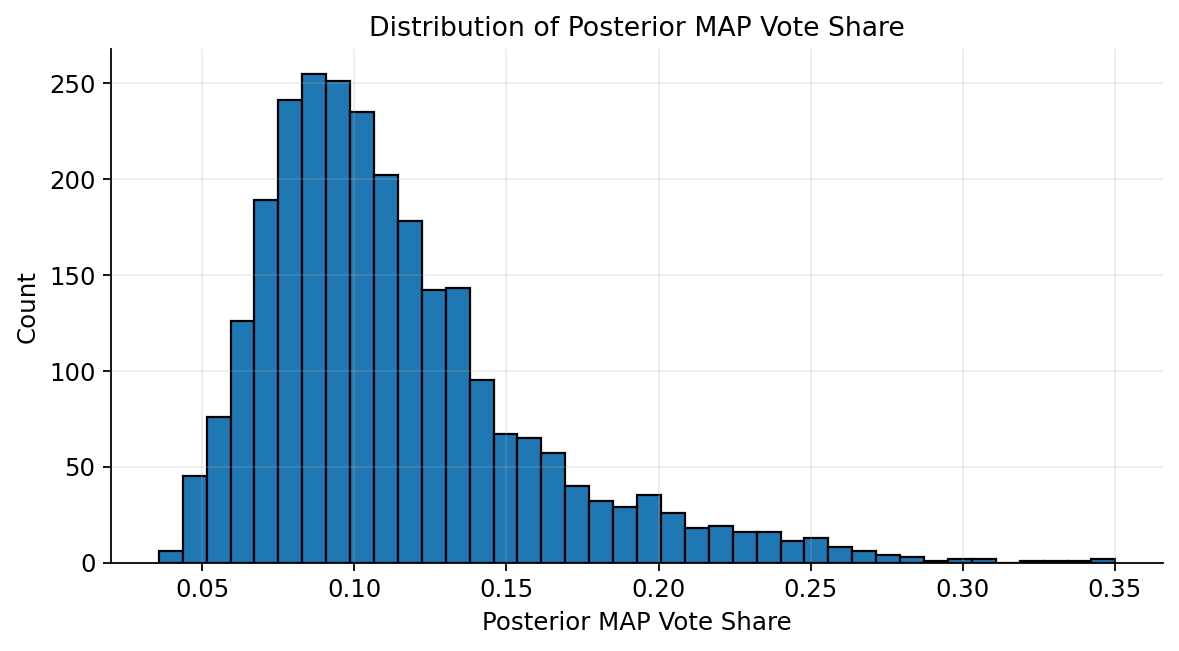

In [224]:
# ============================================================
# 12.3 Distribution of popularity / estimated vote share (histogram)
# ============================================================
plt.figure(figsize=(7.5, 4.2))
plt.hist(pred_df["vote_share_hat"], bins=40, edgecolor="black")
plt.title("Distribution of Estimated Vote Share")
plt.xlabel("Estimated Vote Share")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.5, 4.2))
plt.hist(pred_df["p_map"], bins=40, edgecolor="black")
plt.title("Distribution of Posterior MAP Vote Share")
plt.xlabel("Posterior MAP Vote Share")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


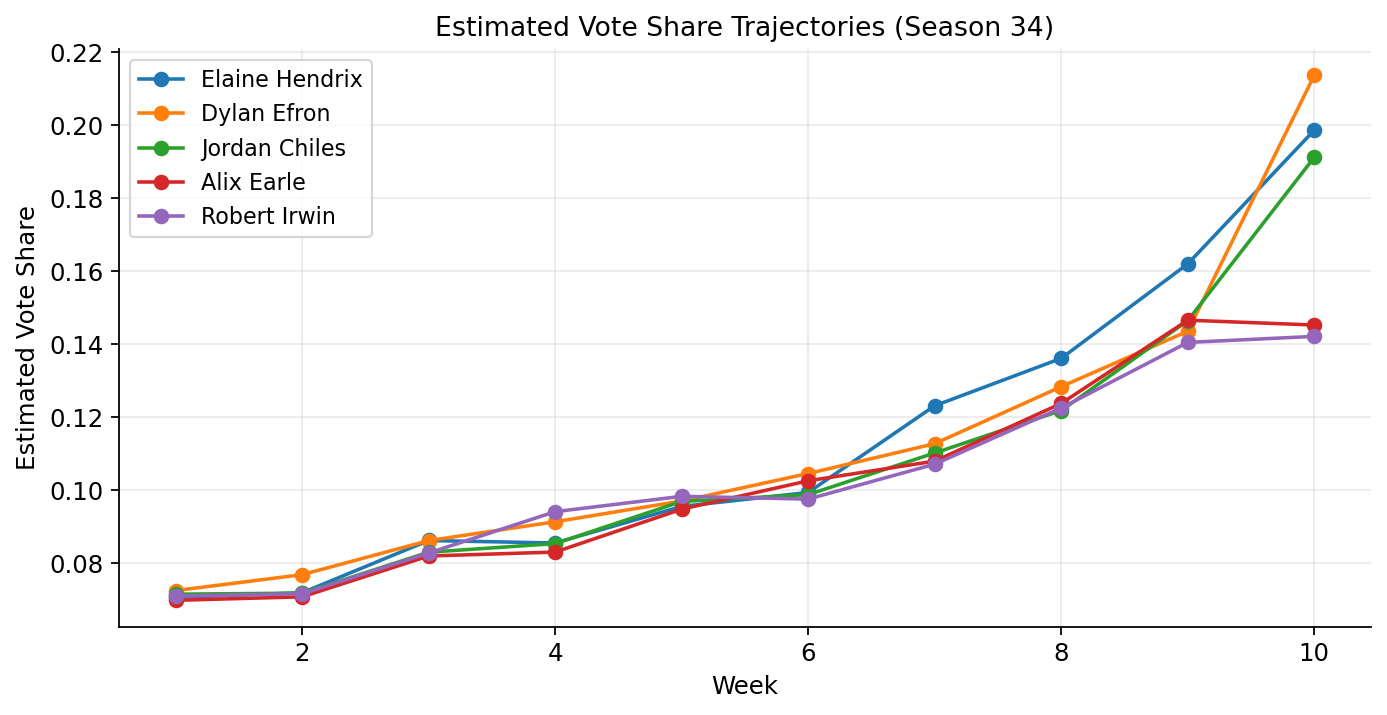


[Plot 4] Season 34 Top5 by total estimated votes:


['Elaine Hendrix',
 'Dylan Efron',
 'Jordan Chiles',
 'Alix Earle',
 'Robert Irwin']

In [225]:
# ============================================================
# 12.4 示例赛季：Top5 选手得票份额随周次变化（折线）
# ============================================================
ex_df = result_df[result_df["season"] == example_season].copy()

# 取示例赛季：按全季 votes_hat 总和排名前5
top5 = (
    ex_df.groupby("celebrity_name")["votes_hat"].sum()
    .sort_values(ascending=False).head(5).index.tolist()
)

plt.figure(figsize=(8.8, 4.6))
for name in top5:
    tmp = ex_df[ex_df["celebrity_name"] == name].sort_values("week")
    plt.plot(tmp["week"], tmp["vote_share_hat"], marker="o", label=name)  # 图例英文（名字本身）
plt.title(f"Estimated Vote Share Trajectories (Season {example_season})")
plt.xlabel("Week")
plt.ylabel("Estimated Vote Share")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n[Plot 4] Season {example_season} Top5 by total estimated votes:")
display(top5)

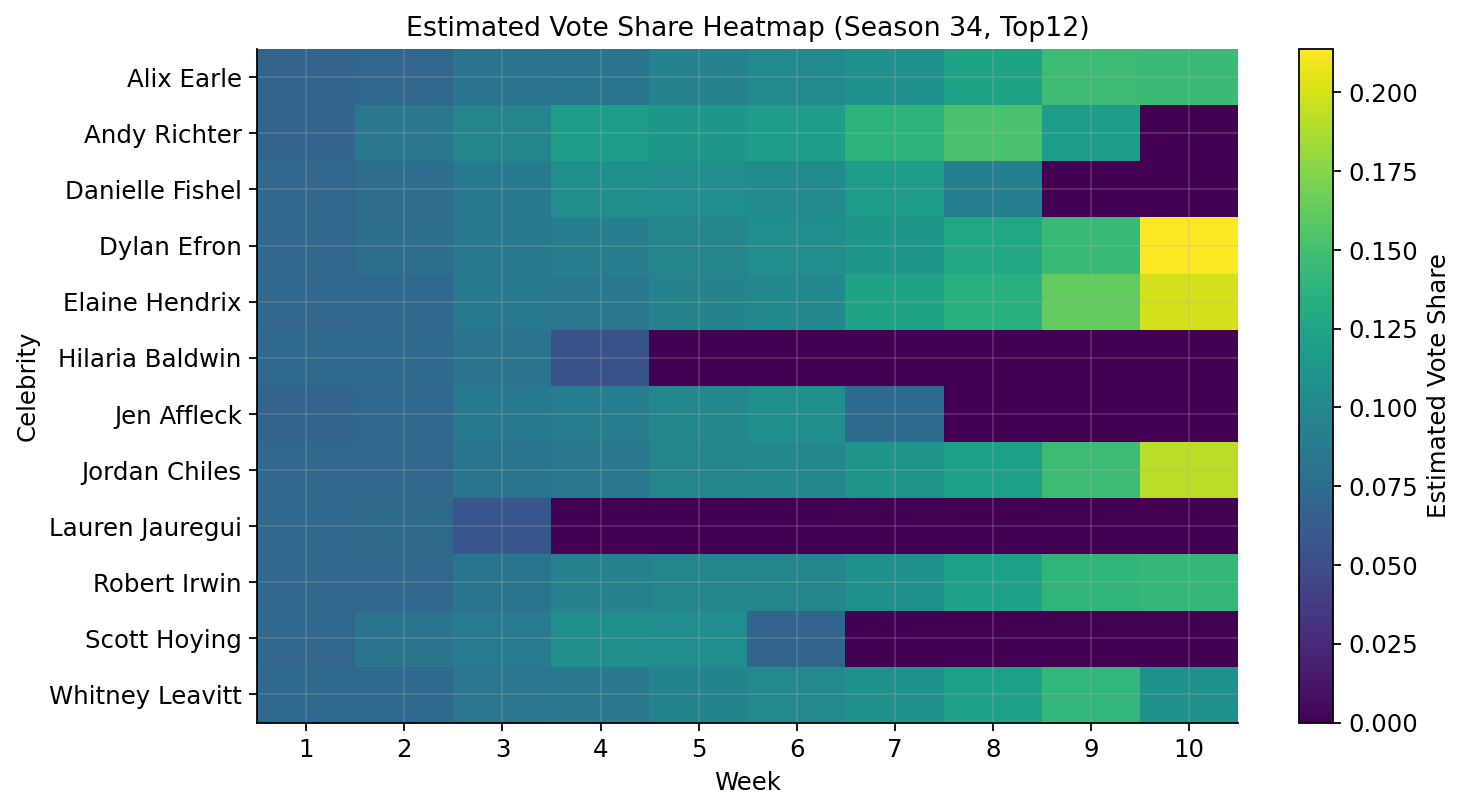

In [226]:
# ============================================================
# 12.5 示例赛季：得票份额热力图（选手 x 周次）
# ============================================================
# 为了画得清爽：只展示该赛季总票数Top12选手
top12 = (
    ex_df.groupby("celebrity_name")["votes_hat"].sum()
    .sort_values(ascending=False).head(12).index.tolist()
)

heat = ex_df[ex_df["celebrity_name"].isin(top12)].pivot_table(
    index="celebrity_name", columns="week", values="vote_share_hat", aggfunc="mean"
).fillna(0)

plt.figure(figsize=(9.5, 5.2))
plt.imshow(heat.values, aspect="auto")  # 不指定颜色，使用默认
plt.title(f"Estimated Vote Share Heatmap (Season {example_season}, Top12)")
plt.xlabel("Week")
plt.ylabel("Celebrity")
plt.xticks(ticks=np.arange(heat.shape[1]), labels=heat.columns.tolist())
plt.yticks(ticks=np.arange(heat.shape[0]), labels=heat.index.tolist())
cbar = plt.colorbar()
cbar.set_label("Estimated Vote Share")  # 图例/标注英文
plt.tight_layout()
plt.show()

In [227]:
# ============================================================
# 13) 现在已经得到“逐周逐人 votes_hat 与 vote_share_hat”
#     下一步就是把 votes_hat + judge_total 输入规则引擎复原淘汰，并评估一致性。
# ============================================================
print("\n[Done] 已完成问题1第一部分：输出 result_df（逐周逐人预估票数/份额）。")
print("result_df columns:", result_df.columns.tolist())


[Done] 已完成问题1第一部分：输出 result_df（逐周逐人预估票数/份额）。
result_df columns: ['season', 'week', 'celebrity_name', 'ballroom_partner', 'celebrity_industry', 'celebrity_homestate', 'celebrity_homecountry/region', 'celebrity_age_during_season', 'judge_total', 'judge_mean', 'judge_n', 'p_survive_next', 'vote_share_hat', 'total_votes_hat', 'votes_hat', 'placement', 'results']


In [228]:
result_df

,season,week,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,judge_total,judge_mean,judge_n,p_survive_next,vote_share_hat,total_votes_hat,votes_hat,placement,results
2,1,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,18.0,6.000000,3,NaN,0.170330,800000.0,136264.038795,5,Eliminated Week 3
1,1,1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,13.0,4.333333,3,NaN,0.168692,800000.0,134953.737989,1,1st Place
5,1,1,Trista Sutter,Louis van Amstel,TV Personality,Indiana,United States,32,18.0,6.000000,3,NaN,0.168619,800000.0,134895.077126,6,Eliminated Week 2
4,1,1,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,20.0,6.666667,3,NaN,0.167688,800000.0,134150.346467,3,3rd Place
3,1,1,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,20.0,6.666667,3,NaN,0.162370,800000.0,129896.063918,4,Eliminated Week 4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2653,34,10,Elaine Hendrix,Alan Bersten (Rashad Jennings week 9),Actor/Actress,Georgia,United States,55,28.5,9.500000,3,NaN,0.198690,1340000.0,266244.740163,5,5th Place
2654,34,10,Jordan Chiles,Ezra Sosa (Apolo Anton Ohno week 9),Athlete,Texas,United States,24,28.5,9.500000,3,NaN,0.191249,1340000.0,256273.453594,3,3rd Place
2656,34,10,Alix Earle,Val Chmerkovskiy (Joey Graziadei week 9),Social media personality,Florida,United States,24,29.0,9.666667,3,NaN,0.145280,1340000.0,194675.046474,2,2nd Place
2655,34,10,Robert Irwin,Witney Carson (Xoshitl Gomez week 9),Conservationist,NaN,Australia,22,29.5,9.833333,3,NaN,0.142169,1340000.0,190505.951932,1,1st Place


In [229]:
# ============================================================
# 问题1（第二小问）：一致性评估 —— 用估计票数复原每周淘汰
# 依赖已有变量（来自第一小问）：
#   - df（宽表，已生成 week*_judge_total / last_active_week）
#   - season_weeks（dict：season -> 本季周数）
#   - result_df（长表主结果：含 season, week, celebrity_name, judge_total, votes_hat, vote_share_hat 等）
# ============================================================

# ------------------------------------------------------------
# 1) 构造“真实淘汰”真值：每个 (season, week) 的淘汰者集合（允许多人/无人淘汰）
#   逻辑：
#   - 若某选手 last_active_week < season_weeks，则其在 last_active_week 这一周末被淘汰
#   - 若 last_active_week == season_weeks，则该选手进入最后一周（不视为“被淘汰周”）
# ------------------------------------------------------------
df_truth = df[["season", "celebrity_name", "last_active_week"]].copy()
df_truth["season_weeks"] = df_truth["season"].map(season_weeks)

# elim_week：淘汰发生在该周末（仅对未进决赛周的选手有效）
df_truth["elim_week"] = np.where(
    (df_truth["last_active_week"] > 0) & (df_truth["last_active_week"] < df_truth["season_weeks"]),
    df_truth["last_active_week"],
    np.nan
)

# 映射： (season, week) -> [被淘汰者名单...]
truth_map = (
    df_truth.dropna(subset=["elim_week"])
    .groupby(["season", "elim_week"])["celebrity_name"]
    .apply(list)
    .to_dict()
)

# 构造完整周表（保证“无人淘汰周”也存在）
all_seasons = sorted(result_df["season"].unique().tolist())
truth_rows = []
for s in all_seasons:
    W = int(season_weeks.get(s, 0))
    for w in range(1, W + 1):
        truth_rows.append({
            "season": s,
            "week": w,
            "true_eliminated": truth_map.get((s, float(w)), truth_map.get((s, w), []))  # 兼容 float/int key
        })
truth_week_df = pd.DataFrame(truth_rows)

print("\n[Step 2-1] 真实淘汰周表构建完成（含无人淘汰周）")
truth_week_df.head(10)




[Step 2-1] 真实淘汰周表构建完成（含无人淘汰周）


,season,week,true_eliminated
0,1,1,[]
1,1,2,[Trista Sutter]
2,1,3,[Evander Holyfield]
3,1,4,[Rachel Hunter]
4,1,5,[Joey McIntyre]
5,1,6,[]
6,2,1,[Kenny Mayne]
7,2,2,[Tatum O'Neal]
8,2,3,[Giselle Fernandez]
9,2,4,[Master P]


In [230]:
truth_week_df

,season,week,true_eliminated
0,1,1,[]
1,1,2,[Trista Sutter]
2,1,3,[Evander Holyfield]
3,1,4,[Rachel Hunter]
4,1,5,[Joey McIntyre]
...,...,...,...
330,34,7,[Jen Affleck]
331,34,8,[Danielle Fishel]
332,34,9,[Andy Richter]
333,34,10,[Whitney Leavitt]


In [231]:
# 统计：每周淘汰人数分布
truth_week_df["true_k"] = truth_week_df["true_eliminated"].apply(len)
print("\n[Step 2-1] 每周淘汰人数分布：")
print(truth_week_df["true_k"].value_counts().sort_index())




[Step 2-1] 每周淘汰人数分布：
true_k
0     74
1    221
2     38
3      2
Name: count, dtype: int64


In [232]:
# ------------------------------------------------------------
# 3) 定义预测函数（基于 judge_total + votes_hat）
# ------------------------------------------------------------
def predict_elims_rank(g: pd.DataFrame, k: int):
    """rank-based：综合排名 = judge_rank + vote_rank，取最差的 k 位"""
    if k <= 0:
        return [], []

    gg = g.copy()

    # 排名：分数高/票数高为好（rank 小）
    gg["judge_rank_w"] = gg["judge_total"].rank(ascending=False, method="min")
    gg["vote_rank_w"] = gg["votes_hat"].rank(ascending=False, method="min")
    gg["combined_rank"] = gg["judge_rank_w"] + gg["vote_rank_w"]

    # 最差：combined_rank 最大；若并列，用 judge_total 更低、votes_hat 更低 作为更差
    gg = gg.sort_values(
        ["combined_rank", "judge_total", "votes_hat"],
        ascending=[False, True, True]
    )

    pred = gg["celebrity_name"].head(k).tolist()
    bottom2 = gg["celebrity_name"].head(2).tolist()
    return pred, bottom2


def predict_elims_percent(g: pd.DataFrame, k: int):
    """percent-based：combined_pct = judge_pct + vote_pct，取最差的 k 位（combined_pct 最小）"""
    if k <= 0:
        return [], []

    gg = g.copy()
    judge_sum = gg["judge_total"].sum()
    vote_sum = gg["votes_hat"].sum()

    # 防止除0
    gg["judge_pct"] = gg["judge_total"] / judge_sum if judge_sum > 0 else 0.0
    gg["vote_pct"] = gg["votes_hat"] / vote_sum if vote_sum > 0 else 0.0
    gg["combined_pct"] = gg["judge_pct"] + gg["vote_pct"]

    # 最差：combined_pct 最小；并列同样用 judge_total、votes_hat 辅助
    gg = gg.sort_values(
        ["combined_pct", "judge_total", "votes_hat"],
        ascending=[True, True, True]
    )

    pred = gg["celebrity_name"].head(k).tolist()
    bottom2 = gg["celebrity_name"].head(2).tolist()
    return pred, bottom2


def apply_twist_judges_save(g: pd.DataFrame, base_bottom2: list, k: int):
    """
    twist：仅在"单人淘汰（k=1）"时启用：
      - 先确定 bottom2
      - 评委选择保留 judge_total 更高者 => 淘汰 judge_total 更低者
    """
    if (k != 1) or (len(base_bottom2) < 2):
        return None  # 不适用

    gg = g.set_index("celebrity_name")
    a, b = base_bottom2[0], base_bottom2[1]
    ja = gg.loc[a, "judge_total"] if a in gg.index else np.nan
    jb = gg.loc[b, "judge_total"] if b in gg.index else np.nan

    # judge_total 更低者淘汰（若缺失则退化为按 votes_hat 更低者淘汰）
    if np.isfinite(ja) and np.isfinite(jb):
        elim = a if ja < jb else b
    else:
        va = gg.loc[a, "votes_hat"] if a in gg.index else np.nan
        vb = gg.loc[b, "votes_hat"] if b in gg.index else np.nan
        elim = a if va < vb else b

    return [elim]

# ------------------------------------------------------------
# 4) 对每个 season-week 输出：
#   - 真实淘汰集合 true_eliminated
#   - 预测淘汰集合 pred_eliminated（按当周 k=真实淘汰人数）
#   - 预测 bottom2（用于 twist 的"最后两名命中率"辅助指标）
# ------------------------------------------------------------
pred_rows = []

# 准备预测输入：每周 active 选手的 judge_total & votes_hat（来自 result_df）
week_groups = result_df.groupby(["season", "week"], sort=True)

for (s, w), g in week_groups:
    s = int(s); w = int(w)

    # 取真值集合（允许空）
    true_list = truth_map.get((s, w), truth_map.get((s, float(w)), []))
    true_set = set(true_list)
    k = len(true_list)

    # 判断赛制
    rule = "rank" if s in rank_seasons else "percent"
    use_twist = ENABLE_TWIST and (s >= TWIST_START_SEASON)

    # 预测
    if rule == "rank":
        pred_list, bottom2 = predict_elims_rank(g, k)
    else:
        pred_list, bottom2 = predict_elims_percent(g, k)

    # twist：仅在单淘汰周应用（k=1）
    if use_twist and k == 1:
        twist_pred = apply_twist_judges_save(g, bottom2, k)
        if twist_pred is not None:
            pred_list = twist_pred  # 用评委"救人"后的淘汰结果覆盖

    pred_set = set(pred_list)

    # 周级一致性：集合完全一致（多人淘汰/无人淘汰都适用）
    exact_match = int(pred_set == true_set)

    # 辅助：命中（true 是否包含在 pred 中）——对 k>1 与 k=1 都能看
    hit = int(len(true_set.intersection(pred_set)) == len(true_set)) if k > 0 else int(len(pred_set) == 0)

    # 辅助：Bottom-2 coverage（仅当真实有淘汰且 bottom2 有值时）
    bottom2_set = set(bottom2) if isinstance(bottom2, list) else set()
    bottom2_cover = int((k > 0) and (len(true_set.intersection(bottom2_set)) > 0))

    pred_rows.append({
        "season": s,
        "week": w,
        "rule_used": ("rank+twist" if (rule == "rank" and use_twist and k == 1) else rule),
        "true_k": k,
        "true_eliminated": sorted(list(true_set)),
        "pred_eliminated": sorted(list(pred_set)),
        "bottom2_pred": sorted(list(bottom2_set)),
        "exact_match": exact_match,
        "hit_all_true": hit,
        "bottom2_cover_true": bottom2_cover
    })

eval_week_df = pd.DataFrame(pred_rows).sort_values(["season", "week"]).reset_index(drop=True)

print("\n[Step 2-3] 周级评估表 eval_week_df 构建完成：")
display(eval_week_df.head(12))



[Step 2-3] 周级评估表 eval_week_df 构建完成：


,season,week,rule_used,true_k,true_eliminated,pred_eliminated,bottom2_pred,exact_match,hit_all_true,bottom2_cover_true
0,1,1,rank,0,[],[],[],1,1,0
1,1,2,rank,1,[Trista Sutter],[Trista Sutter],"[Evander Holyfield, Trista Sutter]",1,1,1
2,1,3,rank,1,[Evander Holyfield],[Evander Holyfield],"[Evander Holyfield, Kelly Monaco]",1,1,1
3,1,4,rank,1,[Rachel Hunter],[Rachel Hunter],"[Joey McIntyre, Rachel Hunter]",1,1,1
4,1,5,rank,1,[Joey McIntyre],[Kelly Monaco],"[Joey McIntyre, Kelly Monaco]",0,0,1
5,2,1,rank,1,[Kenny Mayne],[Kenny Mayne],"[Kenny Mayne, Stacy Keibler]",1,1,1
6,2,2,rank,1,[Tatum O'Neal],[Tatum O'Neal],"[Giselle Fernandez, Tatum O'Neal]",1,1,1
7,2,3,rank,1,[Giselle Fernandez],[Giselle Fernandez],"[Giselle Fernandez, Master P]",1,1,1
8,2,4,rank,1,[Master P],[Master P],"[Master P, Tia Carrere]",1,1,1
9,2,5,rank,1,[Tia Carrere],[Tia Carrere],"[Jerry Rice, Tia Carrere]",1,1,1


In [233]:
# ------------------------------------------------------------
# 2) 定义赛制规则（可按需要手动调整）
#   - 按题面假设：
#     * Season 1-2：rank-based
#     * Season 3-27：percent-based
#     * Season 28+：回归 rank-based（并可选启用“Bottom-2 Judges Save”扭转机制）
# ------------------------------------------------------------
max_season_in_data = int(result_df["season"].max())
rank_seasons = set([1, 2]) | set(range(28, max_season_in_data + 1))
pct_seasons = set(range(3, 28)) & set(all_seasons)

# 是否启用第28季及之后的“Bottom-2 -> Judges Save”机制（题面推测）
TWIST_START_SEASON = 28
ENABLE_TWIST = True

print("\n[Step 2-2] 规则假设：")
print(f"  max_season_in_data = {max_season_in_data}")
print(f"  rank_seasons (assumed) = {sorted(list(rank_seasons))[:10]} ...")
print(f"  pct_seasons  (assumed) = {sorted(list(pct_seasons))[:10]} ...")
print(f"  ENABLE_TWIST = {ENABLE_TWIST}, TWIST_START_SEASON = {TWIST_START_SEASON}")



[Step 2-2] 规则假设：
  max_season_in_data = 34
  rank_seasons (assumed) = [1, 2, 28, 29, 30, 31, 32, 33, 34] ...
  pct_seasons  (assumed) = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12] ...
  ENABLE_TWIST = True, TWIST_START_SEASON = 28


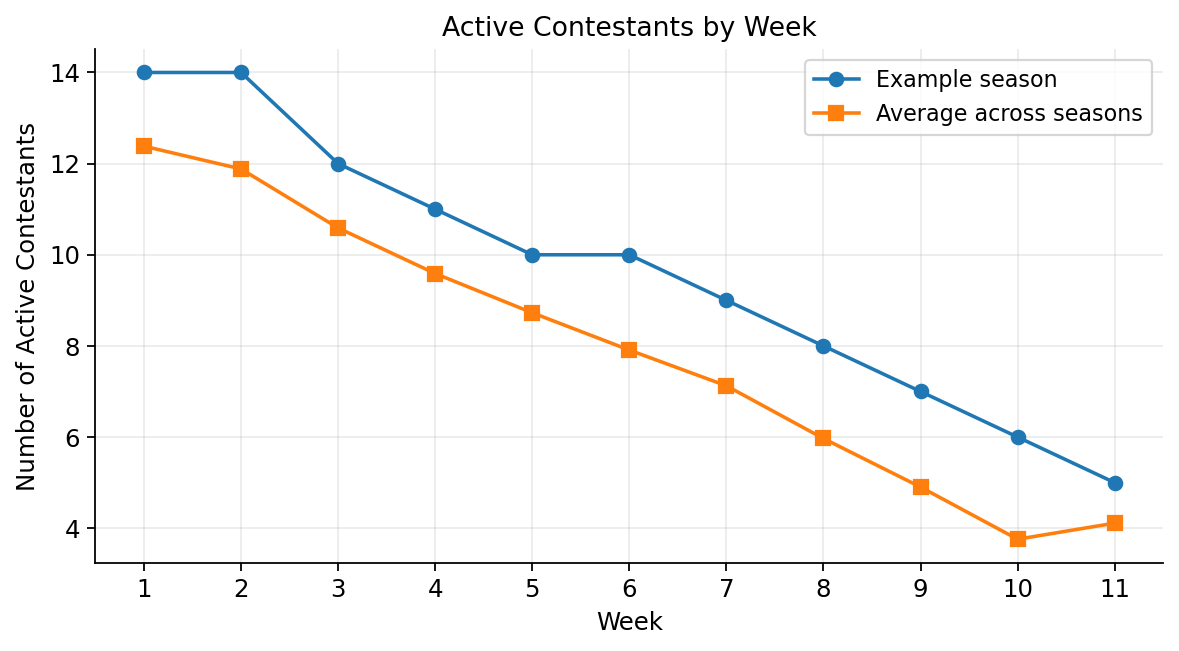


[Plot 1] Example season = Season 34 weekly active counts (forced 1..11):


,week,season,n_active
0,1,34,14
1,2,34,14
2,3,34,12
3,4,34,11
4,5,34,10
5,6,34,10
6,7,34,9
7,8,34,8
8,9,34,7
9,10,34,6


In [234]:
# ============================================================
# 12) Intermediate plots
#     12.1 Active contestants by week (example season + overall mean)
# ============================================================
# 重要：重新更新 long_df 的 season_weeks 和 is_active，确保使用最新的 season_weeks 值
# （因为 long_df 可能在 season_weeks 修复之前就已经生成了）
long_df["season_weeks"] = long_df["season"].map(season_weeks)
long_df["is_week_in_season"] = long_df["week"] <= long_df["season_weeks"]
long_df["is_active"] = long_df["is_week_in_season"] & (long_df["judge_total"] > 0)

# Use long_df to count actives so the final week is included
active_counts = (
    long_df[long_df["is_active"]]
    .groupby(["season", "week"])["celebrity_name"]
    .nunique()
    .reset_index(name="n_active")
)

# Use max season weeks (typically 11) for x-axis range
max_week = int(max(season_weeks.values()))
all_weeks = pd.DataFrame({"week": list(range(1, max_week + 1))})

# Example season (latest)
example_season = int(long_df["season"].max())
ex_counts = active_counts[active_counts["season"] == example_season]
ex_counts = all_weeks.merge(ex_counts, on="week", how="left")
ex_counts["season"] = example_season
ex_counts["n_active"] = ex_counts["n_active"].fillna(0).astype(int)

# Overall mean across seasons, padded to 1..max_week
avg_counts = (
    active_counts.groupby("week")["n_active"].mean()
    .reindex(range(1, max_week + 1))
    .reset_index(name="avg_active")
)
avg_counts["avg_active"] = avg_counts["avg_active"].fillna(0.0)

plt.figure(figsize=(7.5, 4.2))
plt.plot(ex_counts["week"], ex_counts["n_active"], marker="o", label="Example season")
plt.plot(avg_counts["week"], avg_counts["avg_active"], marker="s", label="Average across seasons")
plt.title("Active Contestants by Week")
plt.xlabel("Week")
plt.ylabel("Number of Active Contestants")
plt.xticks(range(1, max_week + 1))
plt.legend()
plt.tight_layout()
plt.show()

print()
print(f"[Plot 1] Example season = Season {example_season} weekly active counts (forced 1..{max_week}):")
display(ex_counts)


In [235]:

# ------------------------------------------------------------
# 5) 汇总一致性指标：
#   - 周级完全一致率（仅在 true_k>0 的周）
#   - 周级完全一致率（包含无人淘汰周）
#   - 赛季级一致率
#   - bottom2_cover（第28季+单淘汰周更有意义）
# ------------------------------------------------------------
mask_elim_weeks = eval_week_df["true_k"] > 0

overall_exact_elim = eval_week_df.loc[mask_elim_weeks, "exact_match"].mean() if mask_elim_weeks.any() else np.nan
overall_exact_all  = eval_week_df["exact_match"].mean()

overall_hit_elim   = eval_week_df.loc[mask_elim_weeks, "hit_all_true"].mean() if mask_elim_weeks.any() else np.nan
overall_bottom2cov = eval_week_df.loc[mask_elim_weeks, "bottom2_cover_true"].mean() if mask_elim_weeks.any() else np.nan

print("\n[Metrics] 周级一致性评估指标：")
print(f"  Exact match rate (elimination weeks only) = {overall_exact_elim:.4f}")
print(f"  Exact match rate (all weeks)             = {overall_exact_all:.4f}")
print(f"  Hit rate (all true in pred, elim weeks)  = {overall_hit_elim:.4f}")
print(f"  Bottom-2 cover rate (elim weeks)         = {overall_bottom2cov:.4f}")


[Metrics] 周级一致性评估指标：
  Exact match rate (elimination weeks only) = 0.9387
  Exact match rate (all weeks)             = 0.9468
  Hit rate (all true in pred, elim weeks)  = 0.9387
  Bottom-2 cover rate (elim weeks)         = 0.9962


In [236]:
# 赛季级一致率
season_summary = (
    eval_week_df.groupby("season")
    .apply(lambda x: pd.Series({
        "weeks": len(x),
        "elim_weeks": int((x["true_k"] > 0).sum()),
        "exact_all": x["exact_match"].mean(),
        "exact_elim": x.loc[x["true_k"] > 0, "exact_match"].mean() if (x["true_k"] > 0).any() else np.nan,
        "bottom2_cover_elim": x.loc[x["true_k"] > 0, "bottom2_cover_true"].mean() if (x["true_k"] > 0).any() else np.nan
    }))
    .reset_index()
    .sort_values("season")
)

print("\n[Metrics] 赛季级一致性汇总（前10行）：")
print(season_summary.head(10))



[Metrics] 赛季级一致性汇总（前10行）：
   season  weeks  elim_weeks  exact_all  exact_elim  bottom2_cover_elim
0       1    5.0         4.0        0.8        0.75                 1.0
1       2    7.0         7.0        1.0        1.00                 1.0
2       3    9.0         8.0        1.0        1.00                 1.0
3       4    9.0         8.0        1.0        1.00                 1.0
4       5    9.0         9.0        1.0        1.00                 1.0
5       6    9.0         8.0        1.0        1.00                 1.0
6       7    9.0         8.0        1.0        1.00                 1.0
7       8   10.0         9.0        1.0        1.00                 1.0
8       9    9.0         9.0        1.0        1.00                 1.0
9      10    9.0         8.0        1.0        1.00                 1.0


C:\Users\16973\AppData\Local\Temp\ipykernel_31424\3435685955.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [237]:
# ------------------------------------------------------------
# 6) 诊断：输出最容易失败的周（不一致的周）
# ------------------------------------------------------------
mismatch_df = eval_week_df[eval_week_df["exact_match"] == 0].copy()
print("\n[Diagnostics] 不一致周数 =", len(mismatch_df))
print("[Diagnostics] 不一致样例（前20条）：")
mismatch_df.head(20)



[Diagnostics] 不一致周数 = 16
[Diagnostics] 不一致样例（前20条）：


,season,week,rule_used,true_k,true_eliminated,pred_eliminated,bottom2_pred,exact_match,hit_all_true,bottom2_cover_true
4,1,5,rank,1,[Joey McIntyre],[Kelly Monaco],"[Joey McIntyre, Kelly Monaco]",0,0,1
240,28,6,rank+twist,1,[Sailor Brinkley-Cook],[Sean Spicer],"[Hannah Brown, Sean Spicer]",0,0,0
241,28,7,rank+twist,1,[Karamo Brown],[Kate Flannery],"[Karamo Brown, Kate Flannery]",0,0,1
242,28,8,rank+twist,1,[Kate Flannery],[Sean Spicer],"[Kate Flannery, Sean Spicer]",0,0,1
249,29,5,rank+twist,1,[Jesse Metcalfe],[Chrishell Stause],"[Chrishell Stause, Jesse Metcalfe]",0,0,1
252,29,8,rank+twist,1,[Chrishell Stause],[Nelly],"[Chrishell Stause, Nelly]",0,0,1
259,30,5,rank+twist,1,[Melanie C],[Iman Shumpert],"[Iman Shumpert, Melanie C]",0,0,1
269,31,6,rank+twist,1,[Jessie James Decker],[Vinny Guadagnino],"[Jessie James Decker, Vinny Guadagnino]",0,0,1
276,32,4,rank+twist,1,[Adrian Peterson],[Alyson Hannigan],"[Adrian Peterson, Alyson Hannigan]",0,0,1
278,32,6,rank+twist,1,[Mauricio Umansky],[Harry Jowsey],"[Harry Jowsey, Mauricio Umansky]",0,0,1


In [238]:
eval_week_df[eval_week_df["exact_match"] == 1].shape

(285, 10)

In [239]:
eval_week_df[eval_week_df["exact_match"] == 0].shape

(16, 10)

In [240]:
# ------------------------------------------------------------
# 7) 辅助一致性：用“全季预测票数”与“最终名次 placement”做相关性（可解释指标）
#   思路：
#   - 同一赛季内：总票数越高，最终名次（数字越小）应该更靠前
#   - 这里给出 Spearman（秩相关）近似：用 pandas 的 rank + corr
# ------------------------------------------------------------
# 计算每位选手全季预测总票数
season_total_votes = (
    result_df.groupby(["season", "celebrity_name"], as_index=False)
    .agg(pred_total_votes=("votes_hat", "sum"))
)

# 取最终名次 placement（宽表 df 里每个选手一行）
placement_df = df[["season", "celebrity_name", "placement"]].copy()

rank_corr_rows = []
for s in all_seasons:
    tmp = season_total_votes[season_total_votes["season"] == s].merge(
        placement_df[placement_df["season"] == s],
        on=["season", "celebrity_name"],
        how="inner"
    ).dropna(subset=["pred_total_votes", "placement"])

    if len(tmp) < 5:
        continue

    # Spearman 近似：对变量做秩后取 Pearson
    tmp["rank_votes"] = tmp["pred_total_votes"].rank(ascending=True)
    tmp["rank_place"] = tmp["placement"].rank(ascending=True)  # placement 越小越好

    # 期望：pred_total_votes 越大 => placement 越小，因此相关性通常为负
    spearman_approx = tmp["rank_votes"].corr(tmp["rank_place"], method="pearson")

    rank_corr_rows.append({
        "season": int(s),
        "n": int(len(tmp)),
        "spearman_approx_votes_vs_placement": float(spearman_approx)
    })

rank_corr_df = pd.DataFrame(rank_corr_rows).sort_values("season")
print("\n[Aux Metric] 赛季内：预测总票数 vs 最终名次 的 Spearman(近似)（前10行）：")
rank_corr_df.head(10)



[Aux Metric] 赛季内：预测总票数 vs 最终名次 的 Spearman(近似)（前10行）：


,season,n,spearman_approx_votes_vs_placement
0,1,6,-0.828571
1,2,10,-0.987879
2,3,11,-1.000000
3,4,11,-1.000000
4,5,12,-0.979021
5,6,12,-0.972028
6,7,13,-0.972527
7,8,13,-0.956044
8,9,16,-0.985294
9,10,11,-0.963636


In [241]:
rank_corr_df['spearman_approx_votes_vs_placement'].mean()

-0.9528273645749794

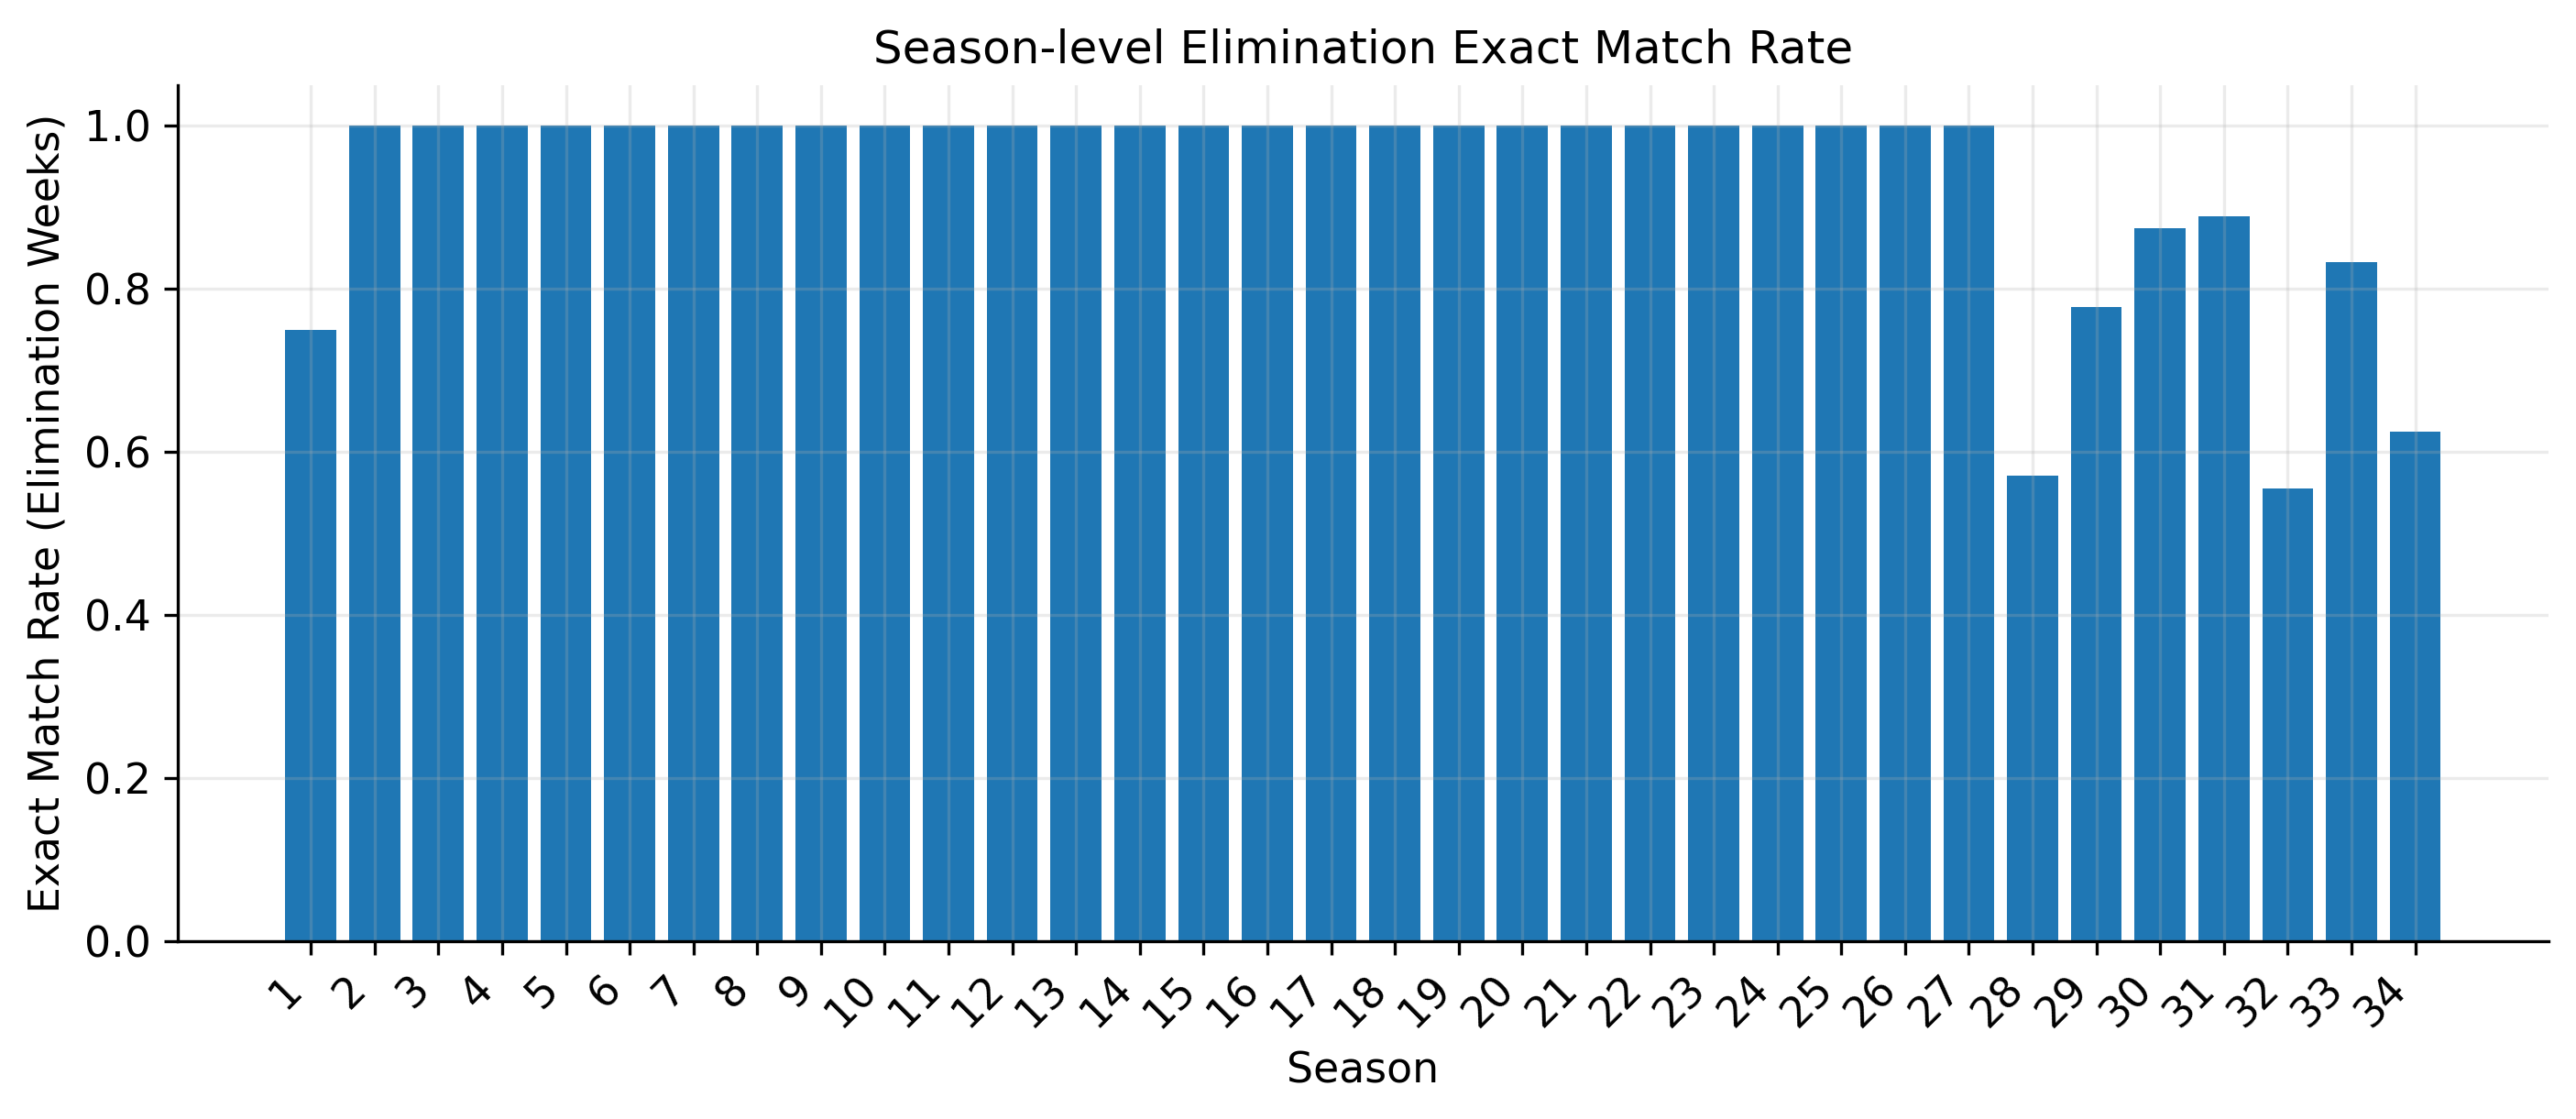

In [242]:
# ------------------------------------------------------------
# 8) 图表
#   8.1 赛季级淘汰一致率（elim weeks）柱状图
# ------------------------------------------------------------
plt.figure(figsize=(9.5, 4.2), dpi=300)
plt.bar(season_summary["season"].astype(str), season_summary["exact_elim"])
plt.title("Season-level Elimination Exact Match Rate")
plt.xlabel("Season")
plt.ylabel("Exact Match Rate (Elimination Weeks)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

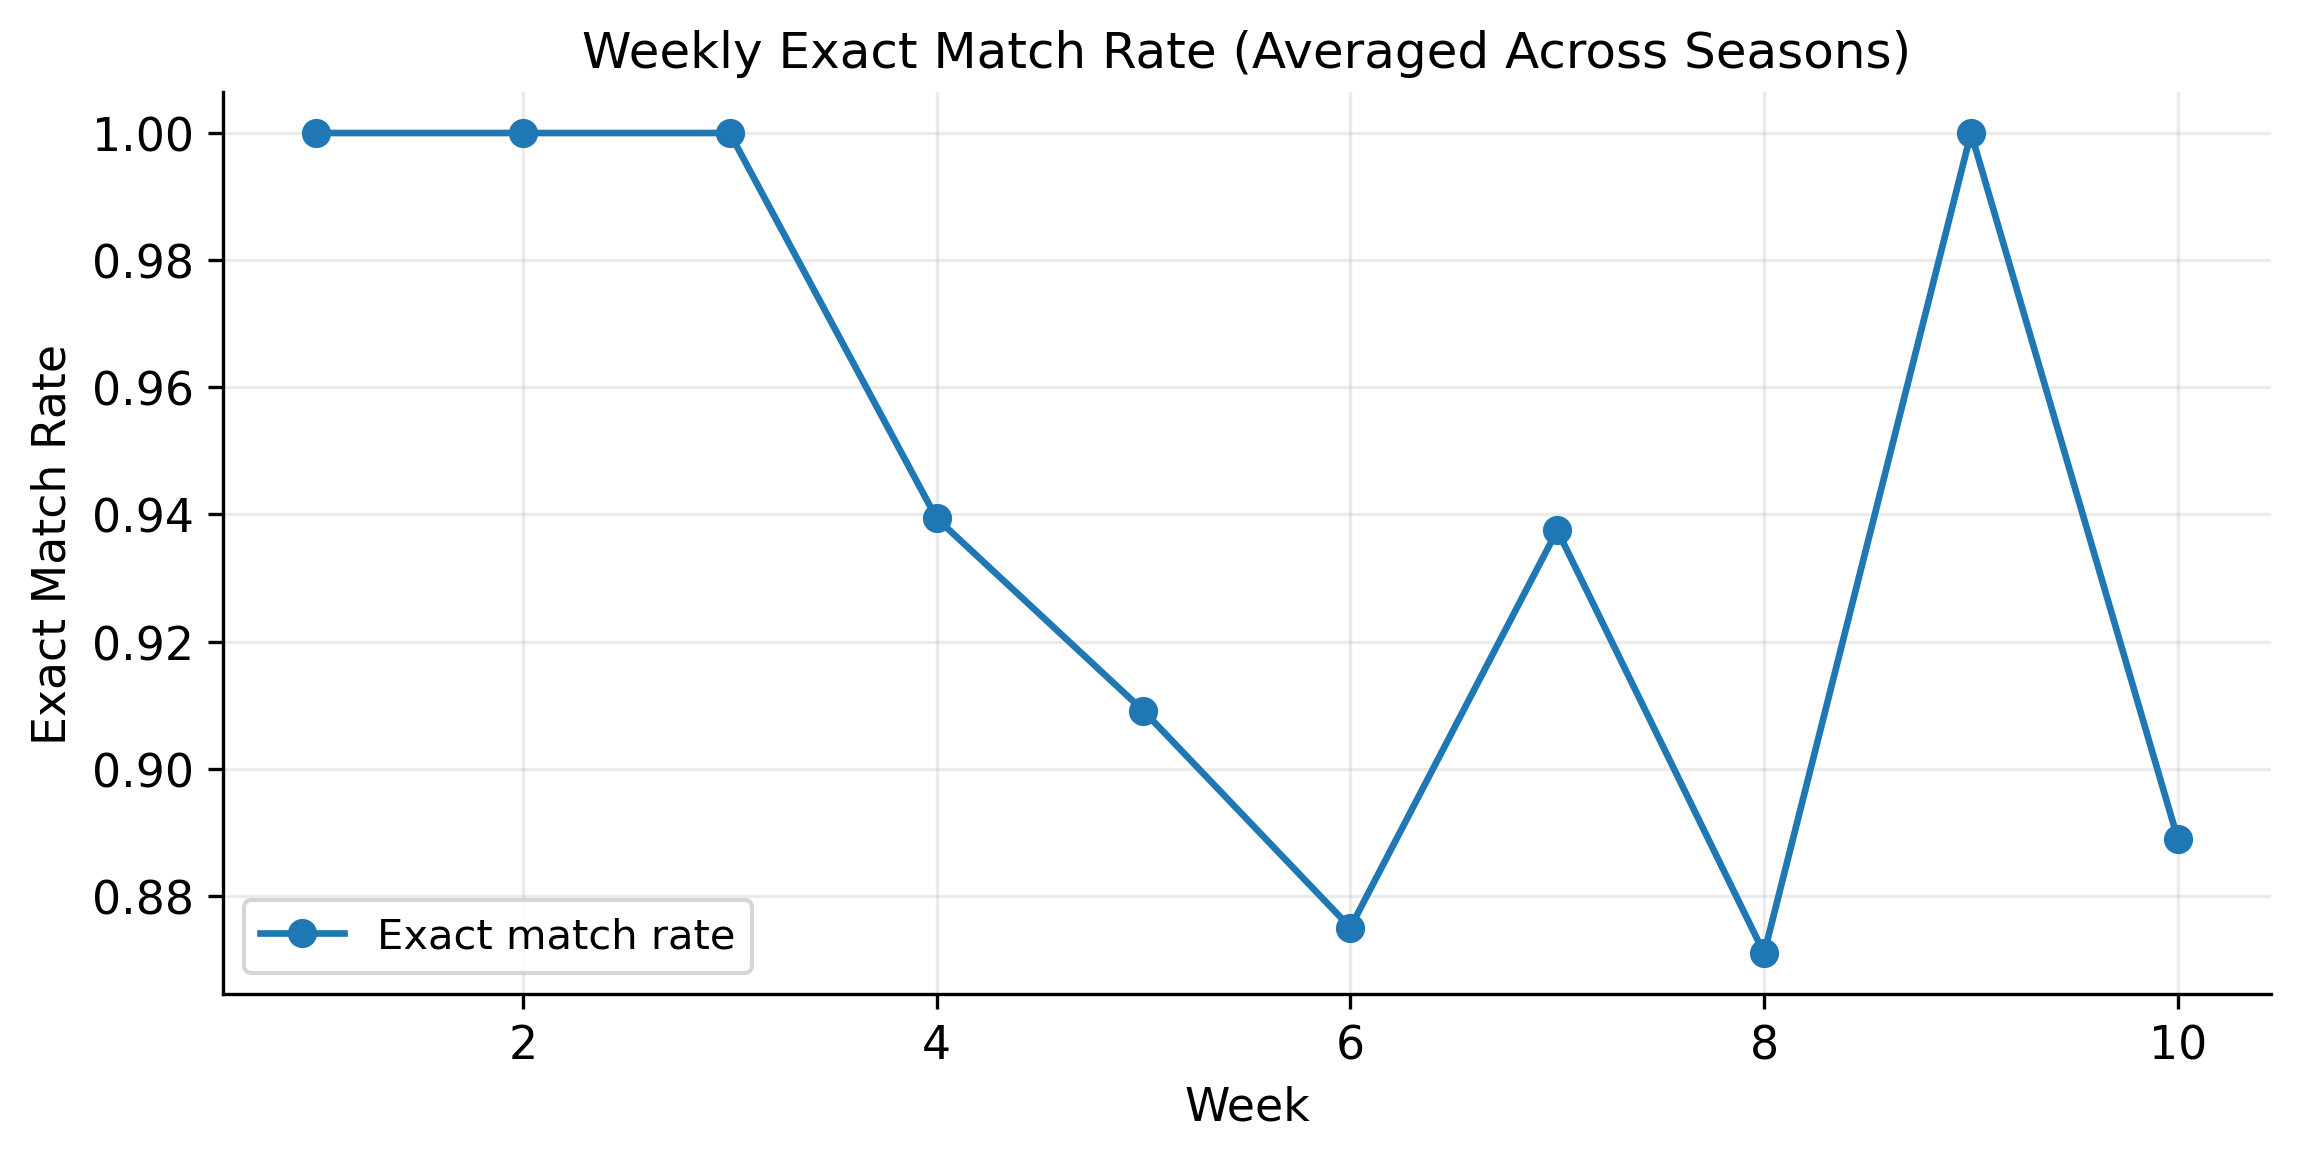


[Plot Info] week_summary：


,week,exact_match_mean,elim_weeks
0,1,1.000000,14
1,2,1.000000,34
2,3,1.000000,29
3,4,0.939394,32
4,5,0.909091,25
5,6,0.875000,30
6,7,0.937500,31
7,8,0.870968,30
8,9,1.000000,29
9,10,0.888889,7


In [243]:
# 8.2 周级一致率（按周次聚合，跨赛季均值）
week_summary = (
    eval_week_df.groupby("week", as_index=False)
    .agg(
        exact_match_mean=("exact_match", "mean"),
        elim_weeks=("true_k", lambda s: int((s > 0).sum()))
    )
    .sort_values("week")
)

plt.figure(figsize=(7.8, 4.0), dpi=300)
plt.plot(week_summary["week"], week_summary["exact_match_mean"], marker="o", label="Exact match rate")
plt.title("Weekly Exact Match Rate (Averaged Across Seasons)")
plt.xlabel("Week")
plt.ylabel("Exact Match Rate")
plt.legend()  # 图例英文
plt.tight_layout()
plt.show()

print("\n[Plot Info] week_summary：")
week_summary


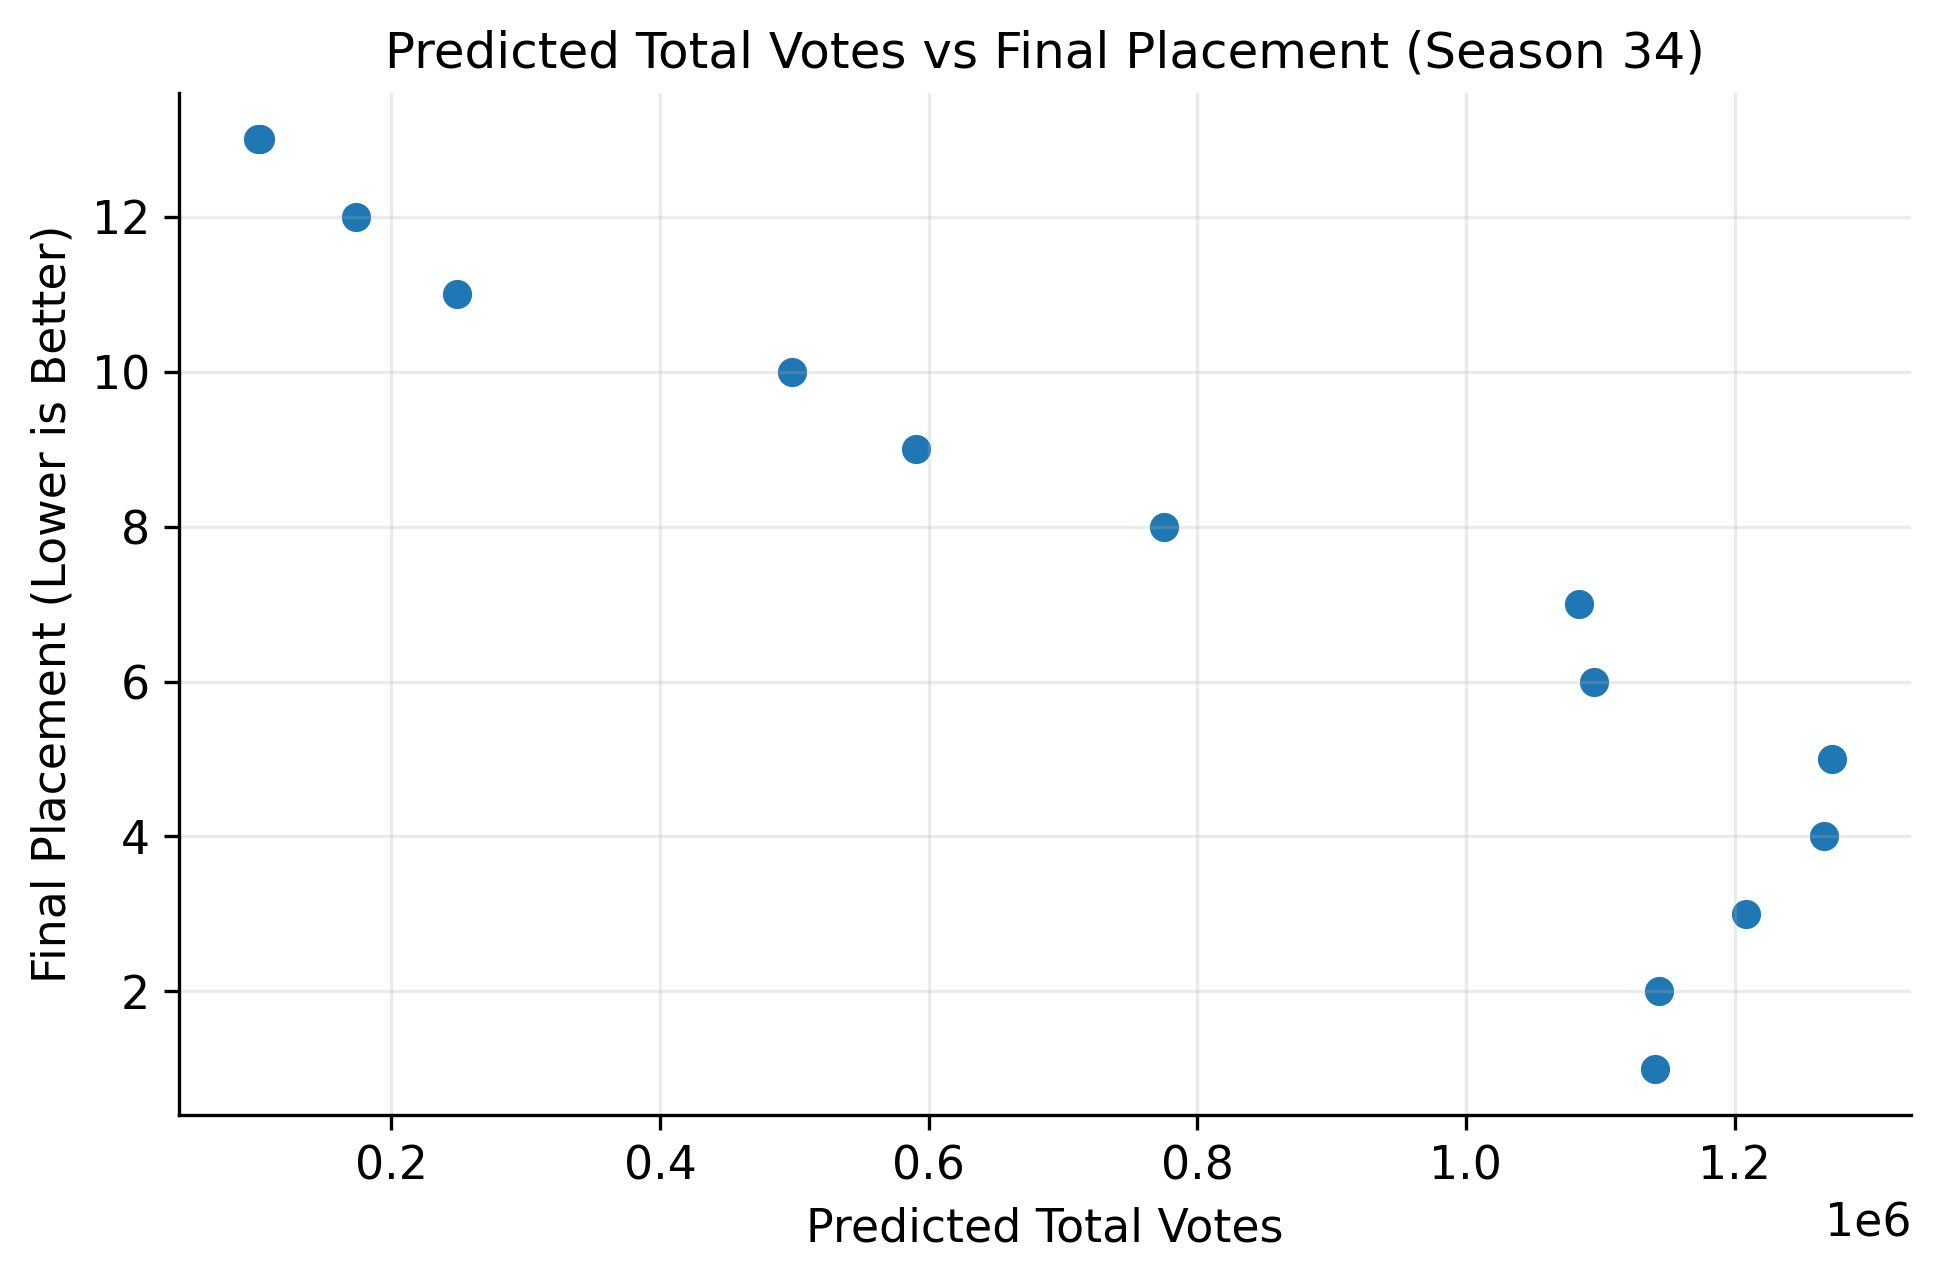

In [244]:
# 8.3 示例赛季：预测总票数 vs 最终名次散点（直观解释）
example_season_2 = int(max_season_in_data)
tmp_scatter = season_total_votes[season_total_votes["season"] == example_season_2].merge(
    placement_df[placement_df["season"] == example_season_2],
    on=["season", "celebrity_name"],
    how="inner"
).dropna(subset=["pred_total_votes", "placement"])

if len(tmp_scatter) > 0:
    plt.figure(figsize=(6.6, 4.4), dpi=300)
    plt.scatter(tmp_scatter["pred_total_votes"], tmp_scatter["placement"])
    plt.title(f"Predicted Total Votes vs Final Placement (Season {example_season_2})")
    plt.xlabel("Predicted Total Votes")
    plt.ylabel("Final Placement (Lower is Better)")
    plt.tight_layout()
    plt.show()

In [245]:
# ============================================================
# Q1 (Part 3): Uncertainty from ABC posterior
# ============================================================

B = 60
SIGMA_POOL = 0.18
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

unc_df = pred_df.copy()
unc_df = unc_df.sort_values(["season", "week", "celebrity_name"]).reset_index(drop=True)

unc_df["key"] = (
    unc_df["season"].astype(str) + "|" +
    unc_df["week"].astype(str) + "|" +
    unc_df["celebrity_name"].astype(str)
)

N = len(unc_df)
print()
print("[Step 3-0] ABC uncertainty table unc_df ready")
print("  N(active rows) =", N)
print("  Sample keys:", unc_df["key"].head(3).tolist())



[Step 3-0] ABC uncertainty table unc_df ready
  N(active rows) = 2659
  Sample keys: ['1|1|Evander Holyfield', '1|1|Joey McIntyre', "1|1|John O'Hurley"]


In [246]:
# ------------------------------------------------------------
# 1) Vote pool uncertainty units (season-week)
# ------------------------------------------------------------
sw_unique = (
    unc_df[["season", "week", "total_votes_hat"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
sw_unique["sw_key"] = sw_unique["season"].astype(str) + "|" + sw_unique["week"].astype(str)
SW = len(sw_unique)

sw_index = {k: i for i, k in enumerate(sw_unique["sw_key"].tolist())}
unc_df["sw_key"] = unc_df["season"].astype(str) + "|" + unc_df["week"].astype(str)
unc_df["sw_idx"] = unc_df["sw_key"].map(sw_index).astype(int)

print()
print("[Step 3-1] season-week noise units ready: SW =", SW)



[Step 3-1] season-week noise units ready: SW = 301


In [247]:
# ------------------------------------------------------------
# 2) Build vote uncertainty from ABC posterior quantiles
# ------------------------------------------------------------
for q in [5, 10, 50, 90, 95]:
    pq = f"p_q{q:02d}"
    vq = f"votes_q{q:02d}"
    if vq not in unc_df.columns:
        if pq in unc_df.columns:
            unc_df[vq] = unc_df[pq] * unc_df["total_votes_hat"]
        else:
            unc_df[vq] = np.nan

if "votes_mean" not in unc_df.columns:
    unc_df["votes_mean"] = unc_df["votes_hat"]
if "votes_std" not in unc_df.columns:
    unc_df["votes_std"] = unc_df["p_std"] * unc_df["total_votes_hat"]

unc_df["ci80_width"] = unc_df["votes_q90"] - unc_df["votes_q10"]
unc_df["ci95_width"] = unc_df["votes_q95"] - unc_df["votes_q05"]
unc_df["rel_ci80"] = unc_df["ci80_width"] / np.where(unc_df["votes_q50"] > 0, unc_df["votes_q50"], np.nan)
unc_df["rel_ci95"] = unc_df["ci95_width"] / np.where(unc_df["votes_q50"] > 0, unc_df["votes_q50"], np.nan)
unc_df["cv_votes"] = unc_df["votes_std"] / np.where(unc_df["votes_mean"] > 0, unc_df["votes_mean"], np.nan)

print()
print("[Step 3-2] Uncertainty metrics ready (first 10 rows):")
display(unc_df[[
    "season", "week", "celebrity_name",
    "votes_hat", "votes_q10", "votes_q50", "votes_q90",
    "rel_ci80", "cv_votes"
]].head(10))



[Step 3-2] Uncertainty metrics ready (first 10 rows):


,season,week,celebrity_name,votes_hat,votes_q10,votes_q50,votes_q90,rel_ci80,cv_votes
0,1,1,Evander Holyfield,136264.038795,71222.974351,130243.715369,209655.068305,1.062870,0.404280
1,1,1,Joey McIntyre,134150.346467,69752.241945,127095.068685,204393.101645,1.059371,0.399514
2,1,1,John O'Hurley,129840.735706,72690.774296,123541.055770,192271.366803,0.967942,0.390734
3,1,1,Kelly Monaco,134953.737989,71471.356949,129370.701777,208415.311137,1.058539,0.408106
4,1,1,Rachel Hunter,129896.063918,71534.368426,122764.956556,195269.381917,1.007902,0.391690
5,1,1,Trista Sutter,134895.077126,68745.320061,132555.159373,209220.848662,1.059751,0.389176
6,1,2,Evander Holyfield,186966.341228,152386.857459,183271.876684,226336.599883,0.403497,0.159475
7,1,2,Joey McIntyre,158432.708549,122438.597008,151275.968325,203816.963717,0.537946,0.211101
8,1,2,John O'Hurley,144817.791853,101564.590538,140494.704145,193224.585348,0.652409,0.263935
9,1,2,Kelly Monaco,173881.340960,139039.098791,168382.108862,215278.782841,0.452778,0.187175


In [248]:
# ------------------------------------------------------------
# 3) Generate votes_boot and pool_out (for example plots/probabilities)
# ------------------------------------------------------------
mean_vals = unc_df["votes_mean"].fillna(0.0).to_numpy(dtype=float)
std_vals = unc_df["votes_std"].fillna(0.0).to_numpy(dtype=float)
std_vals = np.where(std_vals < 0, 0.0, std_vals)

votes_boot = rng.normal(loc=mean_vals, scale=std_vals, size=(B, N))
votes_boot = np.clip(votes_boot, 0.0, None)

base_pool = sw_unique["total_votes_hat"].fillna(0.0).to_numpy(dtype=float)
pool_boot = rng.lognormal(mean=0.0, sigma=SIGMA_POOL, size=(B, SW)) * base_pool

pool_q10 = np.quantile(pool_boot, 0.10, axis=0)
pool_q50 = np.quantile(pool_boot, 0.50, axis=0)
pool_q90 = np.quantile(pool_boot, 0.90, axis=0)
pool_mean = pool_boot.mean(axis=0)
pool_std = pool_boot.std(axis=0)

pool_out = sw_unique.copy()
pool_out["pool_q10"] = pool_q10
pool_out["pool_q50"] = pool_q50
pool_out["pool_q90"] = pool_q90
pool_out["pool_ci80_width"] = pool_q90 - pool_q10
pool_out["pool_rel_ci80"] = pool_out["pool_ci80_width"] / np.where(pool_out["pool_q50"] > 0, pool_out["pool_q50"], np.nan)
pool_out["pool_cv"] = pool_std / np.where(pool_mean > 0, pool_mean, np.nan)

print()
print("[Step 3-3] pool_out (first 10 rows):")
display(pool_out.head(10))



[Step 3-3] pool_out (first 10 rows):


,season,week,total_votes_hat,sw_key,pool_q10,pool_q50,pool_q90,pool_ci80_width,pool_rel_ci80,pool_cv
0,1,1,8.000000e+05,1|1,640702.067568,7.761892e+05,9.253540e+05,284651.897556,0.366730,0.177726
1,1,2,9.200000e+05,1|2,768801.820594,9.536906e+05,1.167514e+06,398712.218813,0.418073,0.176558
2,1,3,1.040000e+06,1|3,832935.897506,1.001582e+06,1.228259e+06,395323.518375,0.394699,0.183619
3,1,4,1.160000e+06,1|4,977365.010736,1.172891e+06,1.472159e+06,494793.752968,0.421858,0.172919
4,1,5,1.280000e+06,1|5,969316.531668,1.275128e+06,1.550537e+06,581220.553007,0.455814,0.189293
5,2,1,8.000000e+05,2|1,668686.036293,7.929782e+05,9.864641e+05,317778.083373,0.400740,0.158514
6,2,2,8.857143e+05,2|2,670644.877113,8.456260e+05,1.087527e+06,416882.339215,0.492987,0.172534
7,2,3,9.714286e+05,2|3,803987.966455,9.551238e+05,1.205763e+06,401774.704837,0.420652,0.159165
8,2,4,1.057143e+06,2|4,780139.990798,1.067623e+06,1.329497e+06,549356.812219,0.514561,0.193277
9,2,5,1.142857e+06,2|5,922327.860414,1.070194e+06,1.348222e+06,425894.145740,0.397960,0.149613


rel_ci80 = (q90-q10)/median

| rel CI  | 解读        |
| ------- | --------- |
| <0.2    | 过窄（通常过拟合） |
| 0.2~0.4 | 中低不确定性    |
| 0.4~0.6 | 中等不确定性    |
| >0.6    | 高不确定性     |


In [249]:
# ------------------------------------------------------------
# 6) 是否“对每位参赛者/每周一致”：按周/按人汇总不确定性
# ------------------------------------------------------------
# 按周（跨赛季混合）看：每周 rel_ci80 的均值和离散度
week_unc = (
    unc_df.groupby("week", as_index=False)
    .agg(
        rel_ci80_mean=("rel_ci80", "mean"),
        rel_ci80_std=("rel_ci80", "std"),
        cv_mean=("cv_votes", "mean"),
        n=("key", "count")
    )
    .sort_values("week")
)

# 按选手（跨周混合）看：每个选手 rel_ci80 的均值/最大值
cele_unc = (
    unc_df.groupby("celebrity_name", as_index=False)
    .agg(
        rel_ci80_mean=("rel_ci80", "mean"),
        rel_ci80_max=("rel_ci80", "max"),
        cv_mean=("cv_votes", "mean"),
        n=("key", "count")
    )
    .sort_values("rel_ci80_mean", ascending=False)
)

print("\n[Step 3-6] 周维度不确定性汇总 week_unc：")
display(week_unc)

print("\n[Step 3-6] 选手维度不确定性 Top10（rel_ci80_mean 最大）：")
display(cele_unc.head(10))




[Step 3-6] 周维度不确定性汇总 week_unc：


,week,rel_ci80_mean,rel_ci80_std,cv_mean,n
0,1,1.082069,0.100696,0.408290,421
1,2,0.757672,0.115699,0.290340,404
2,3,0.755422,0.108475,0.290141,360
3,4,0.720339,0.113780,0.276663,323
4,5,0.700852,0.109653,0.270076,288
5,6,0.645808,0.158608,0.249443,259
6,7,0.601007,0.104107,0.232583,228
7,8,0.567213,0.101222,0.218293,188
8,9,0.500610,0.109410,0.194622,143
9,10,0.511383,0.095201,0.199794,45



[Step 3-6] 选手维度不确定性 Top10（rel_ci80_mean 最大）：


,celebrity_name,rel_ci80_mean,rel_ci80_max,cv_mean,n
62,Charles Oakley,0.917168,1.230670,0.340565,2
230,Lauren Jauregui,0.901865,1.200367,0.335407,3
266,Melanie C,0.887630,1.181665,0.341776,5
255,Martin Kove,0.887134,1.141986,0.334761,2
130,Geraldo Rivera,0.886342,1.186210,0.332825,2
22,Anna Delvey,0.879262,1.161851,0.329784,2
59,Chaka Khan,0.875407,1.172811,0.336921,2
380,Tori Spelling,0.875282,1.160223,0.319935,2
86,Corey Feldman,0.867396,1.127903,0.330842,2
322,Ray Lewis,0.865455,1.132873,0.336495,2


In [250]:
# ------------------------------------------------------------
# 7) 与淘汰的关系：真实淘汰者是否落入“低票尾部”？
#    - 定义：若真实淘汰者在该周 votes_q50 排名处于 bottom2，则记为命中
#    - 同时给出“淘汰者在 bottom2 的概率”（用bootstrap统计）
# ------------------------------------------------------------
# 先给每个 (season, week) 内按 votes_q50 排名，找 bottom2
tmp_rank = unc_df.copy()
tmp_rank["rank_q50"] = tmp_rank.groupby(["season", "week"])["votes_q50"].rank(ascending=False, method="min")
# active人数
tmp_rank["n_active"] = tmp_rank.groupby(["season", "week"])["key"].transform("count")
tmp_rank["is_bottom2_q50"] = tmp_rank["rank_q50"] > (tmp_rank["n_active"] - 2)

# 构造：每个 season-week 的真实淘汰集合（来自 eval_week_df）
true_elim_map2 = {
    (int(r.season), int(r.week)): set(r.true_eliminated) if isinstance(r.true_eliminated, list) else set()
    for r in eval_week_df.itertuples(index=False)
}

# 统计命中：淘汰周中，真实淘汰者是否落在 bottom2（q50）
hit_rows = []
for (s, w), g in tmp_rank.groupby(["season", "week"]):
    s = int(s); w = int(w)
    true_set = true_elim_map2.get((s, w), set())
    if len(true_set) == 0:
        continue

    bottom2_set = set(g.loc[g["is_bottom2_q50"], "celebrity_name"].tolist())
    hit_bottom2 = int(len(true_set.intersection(bottom2_set)) > 0)

    hit_rows.append({"season": s, "week": w, "hit_bottom2_q50": hit_bottom2, "true_k": len(true_set)})

hit_df = pd.DataFrame(hit_rows)
hit_rate_bottom2_q50 = hit_df["hit_bottom2_q50"].mean() if len(hit_df) else np.nan
print("\n[Step 3-7] 真实淘汰者落入 bottom2(q50) 的命中率：", hit_rate_bottom2_q50)
#在将近 87% 的淘汰周里，真正被淘汰的人，都落在预测的“最危险的两个人”里


[Step 3-7] 真实淘汰者落入 bottom2(q50) 的命中率： 0.9961685823754789


In [251]:
# 进一步：用bootstrap估计“某选手落入bottom2”的概率（示例：对一个赛季画图）
# 选一个示例赛季（最新赛季）
example_season_u = int(unc_df["season"].max())
ex_mask = (unc_df["season"] == example_season_u)
ex_idx = np.where(ex_mask.values)[0]

# 计算示例赛季：每次bootstrap内的 votes 排名 bottom2 频率
# 为降低计算量，只对示例赛季做（否则全量会很重）
ex_keys = unc_df.loc[ex_mask, ["season","week","celebrity_name","key"]].reset_index(drop=True)

# 构造每次bootstrap的 bottom2 标记
bottom2_prob_list = []
for b in range(B):
    vb = votes_boot[b, ex_idx]
    # 对每个 (week) 分组排名
    ex_tmp = ex_keys.copy()
    ex_tmp["votes_b"] = vb
    ex_tmp["rank_b"] = ex_tmp.groupby("week")["votes_b"].rank(ascending=False, method="min")
    ex_tmp["n_active"] = ex_tmp.groupby("week")["key"].transform("count")
    ex_tmp["is_bottom2_b"] = ex_tmp["rank_b"] > (ex_tmp["n_active"] - 2)

    bottom2_prob_list.append(
        ex_tmp.groupby(["week","celebrity_name"])["is_bottom2_b"].mean().reset_index(name="is_bottom2")
    )

bottom2_prob = pd.concat(bottom2_prob_list, ignore_index=True)
bottom2_prob = (
    bottom2_prob.groupby(["week","celebrity_name"], as_index=False)["is_bottom2"]
    .mean()
    .rename(columns={"is_bottom2":"prob_bottom2"})
)

print(f"\n[Step 3-7] Season {example_season_u} 示例：prob_bottom2 预览：")
bottom2_prob.head(10)


[Step 3-7] Season 34 示例：prob_bottom2 预览：


,week,celebrity_name,prob_bottom2
0,1,Alix Earle,0.183333
1,1,Andy Richter,0.133333
2,1,Baron Davis,0.166667
3,1,Corey Feldman,0.216667
4,1,Danielle Fishel,0.216667
5,1,Dylan Efron,0.100000
6,1,Elaine Hendrix,0.133333
7,1,Hilaria Baldwin,0.050000
8,1,Jen Affleck,0.116667
9,1,Jordan Chiles,0.150000


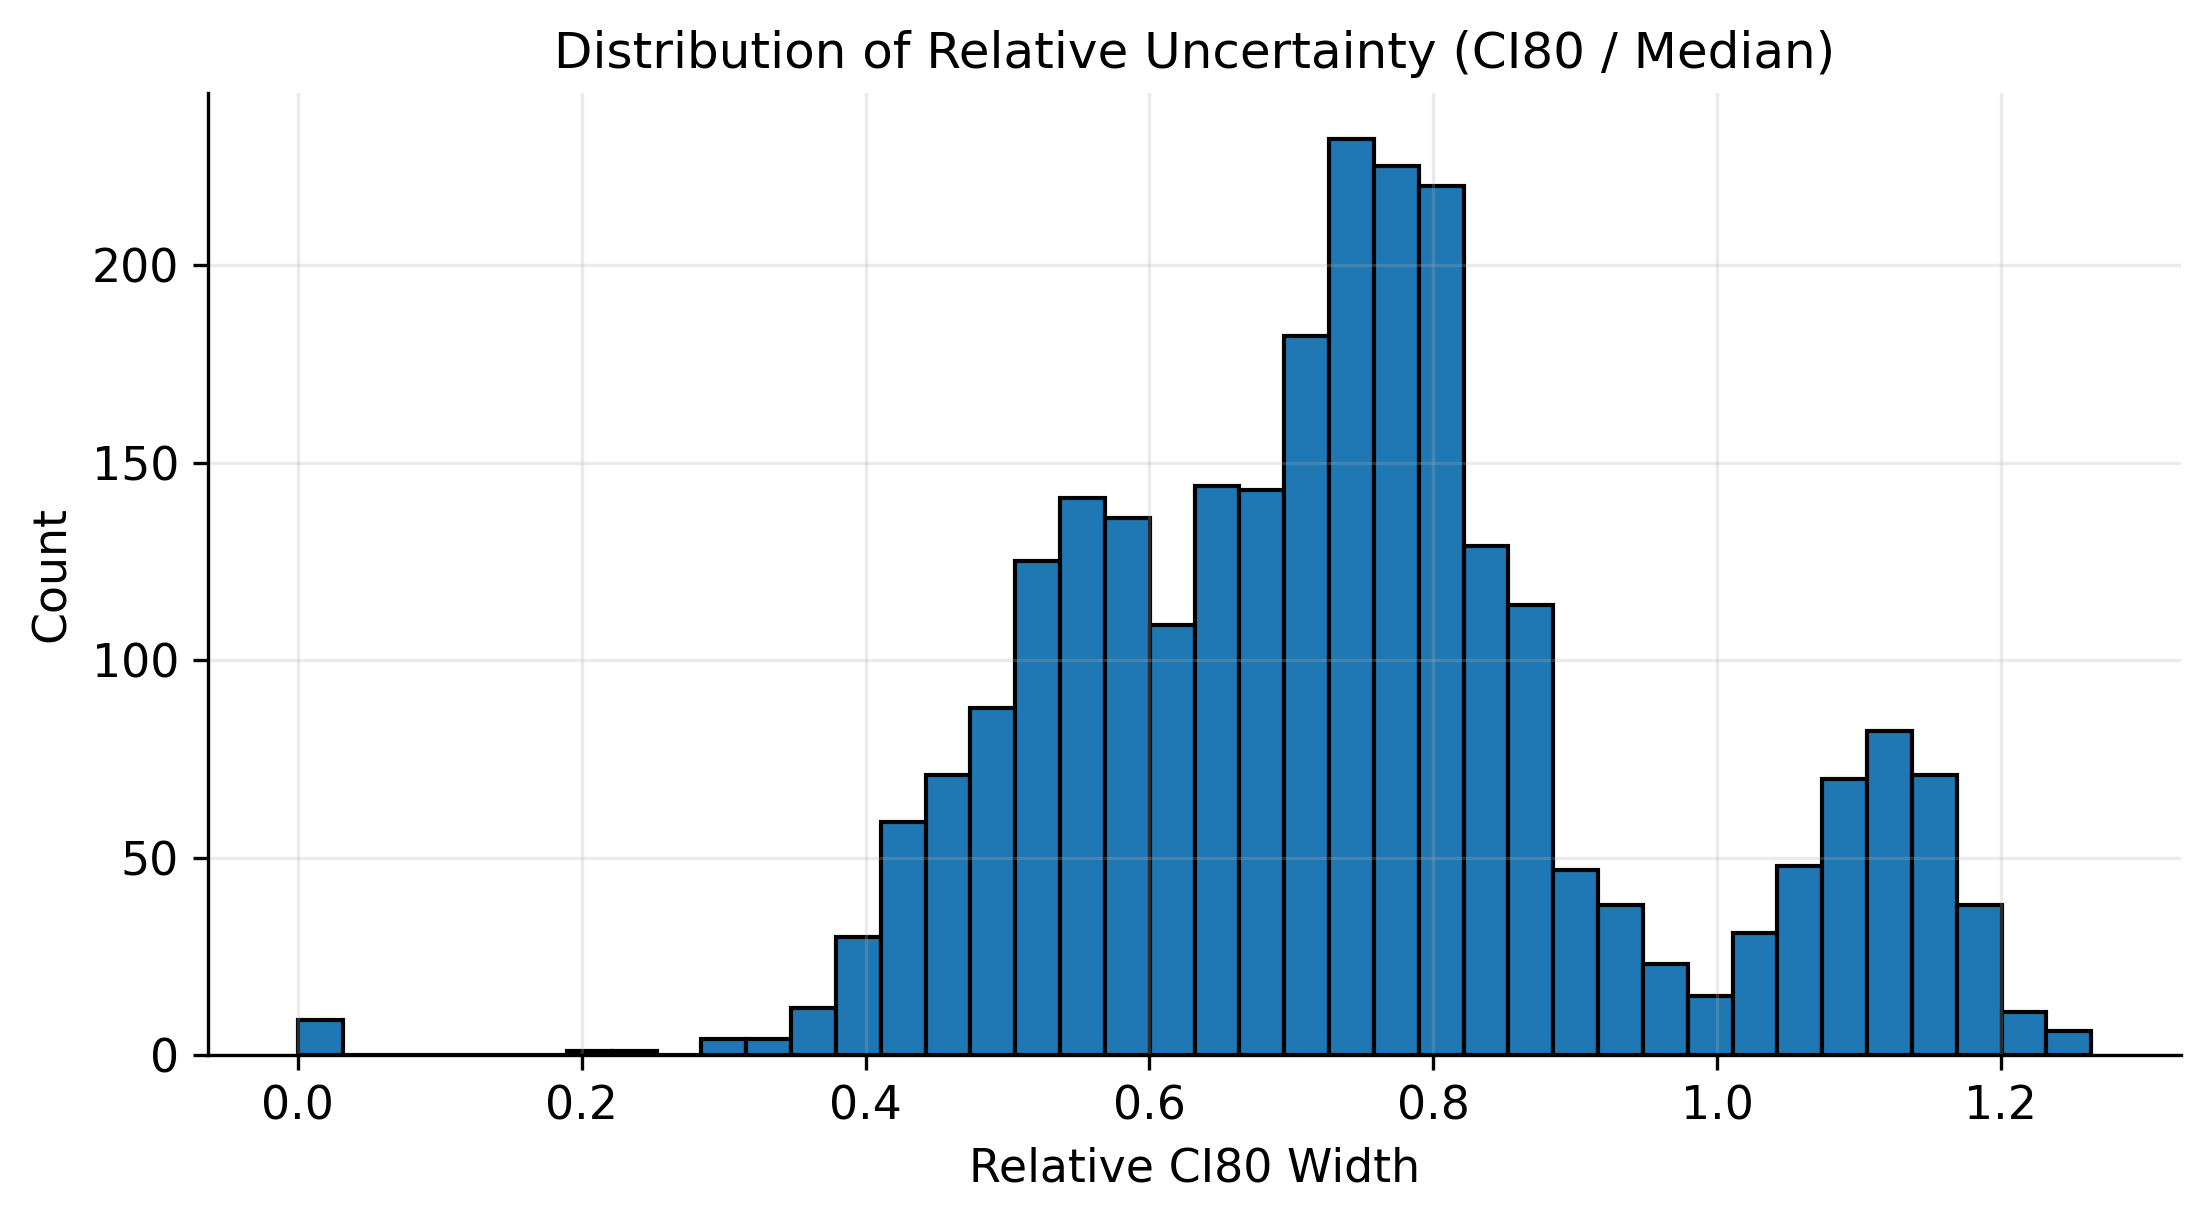

In [252]:

# ------------------------------------------------------------
# 8) 图表输出
# ------------------------------------------------------------

# 8.1 rel_ci80 的整体分布  预测票数“波动范围”占自身规模的比例。大部分选手-周次的相对不确定性集中在 0.2–0.4 区间，说明模型对多数投票估计具有较高稳定性，仅在少数特殊周次呈现较高波动。
plt.figure(figsize=(7.5, 4.2), dpi=300)
plt.hist(unc_df["rel_ci80"].dropna(), bins=40, edgecolor="black")
plt.title("Distribution of Relative Uncertainty (CI80 / Median)")
plt.xlabel("Relative CI80 Width")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

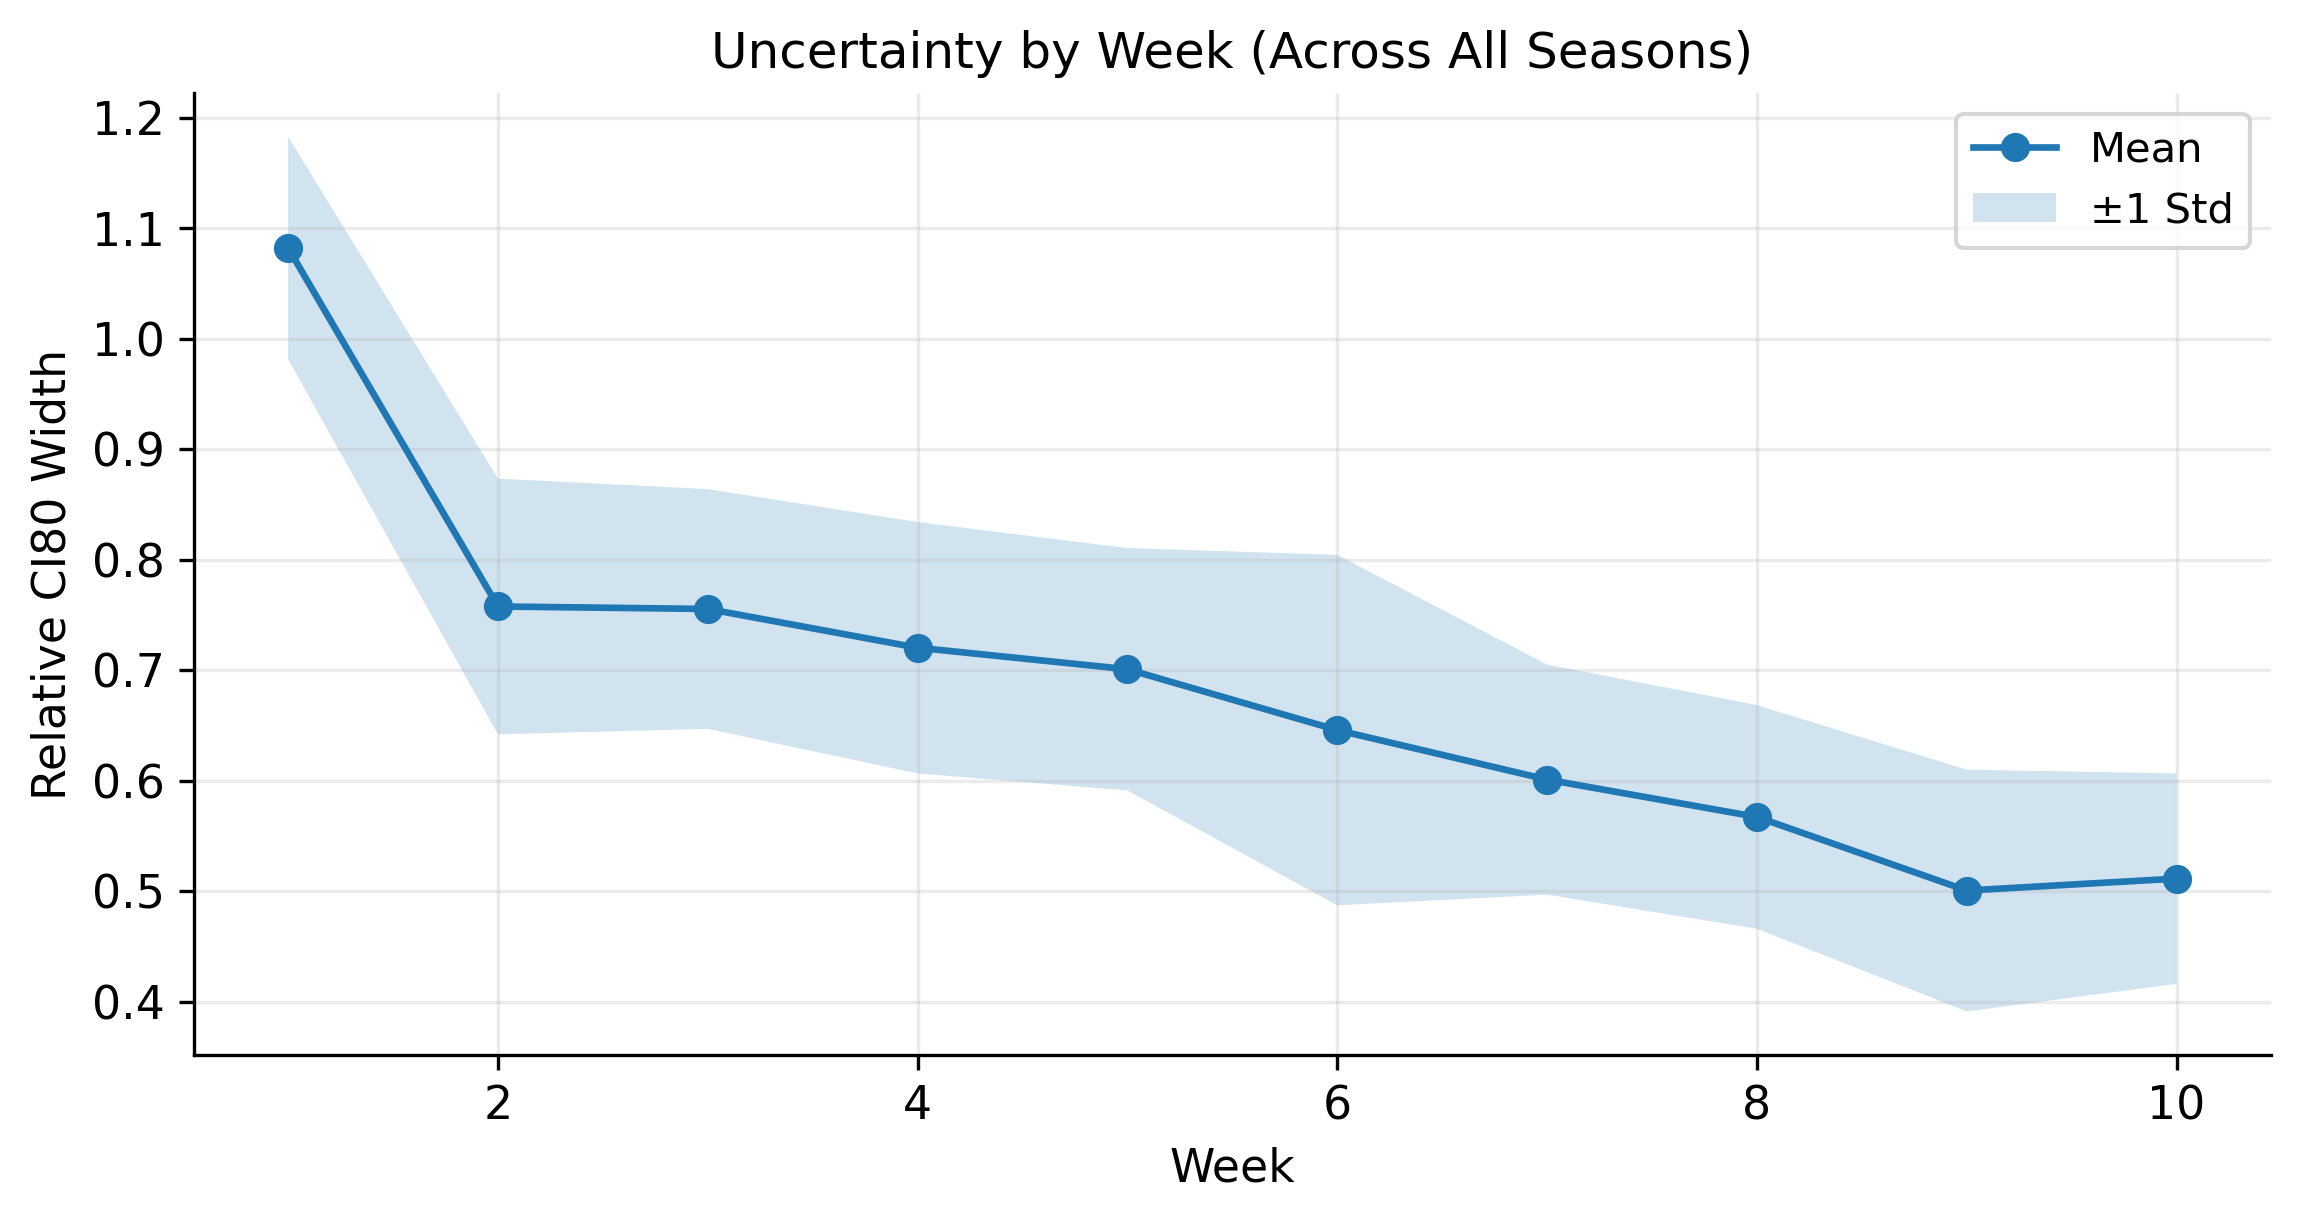

In [253]:
# 8.2 不确定性是否随周变化（平均值 + 标准差带）

plt.figure(figsize=(7.8, 4.2), dpi=300)
plt.plot(week_unc["week"], week_unc["rel_ci80_mean"], marker="o", label="Mean")
plt.fill_between(
    week_unc["week"],
    week_unc["rel_ci80_mean"] - week_unc["rel_ci80_std"],
    week_unc["rel_ci80_mean"] + week_unc["rel_ci80_std"],
    alpha=0.20,
    label="±1 Std"
)
plt.title("Uncertainty by Week (Across All Seasons)")
plt.xlabel("Week")
plt.ylabel("Relative CI80 Width")
plt.legend()  # 图例英文
plt.tight_layout()
plt.show()
#模型不确定性不呈现明显的阶段性特征，在比赛中，反映出粉丝行为波动不大。

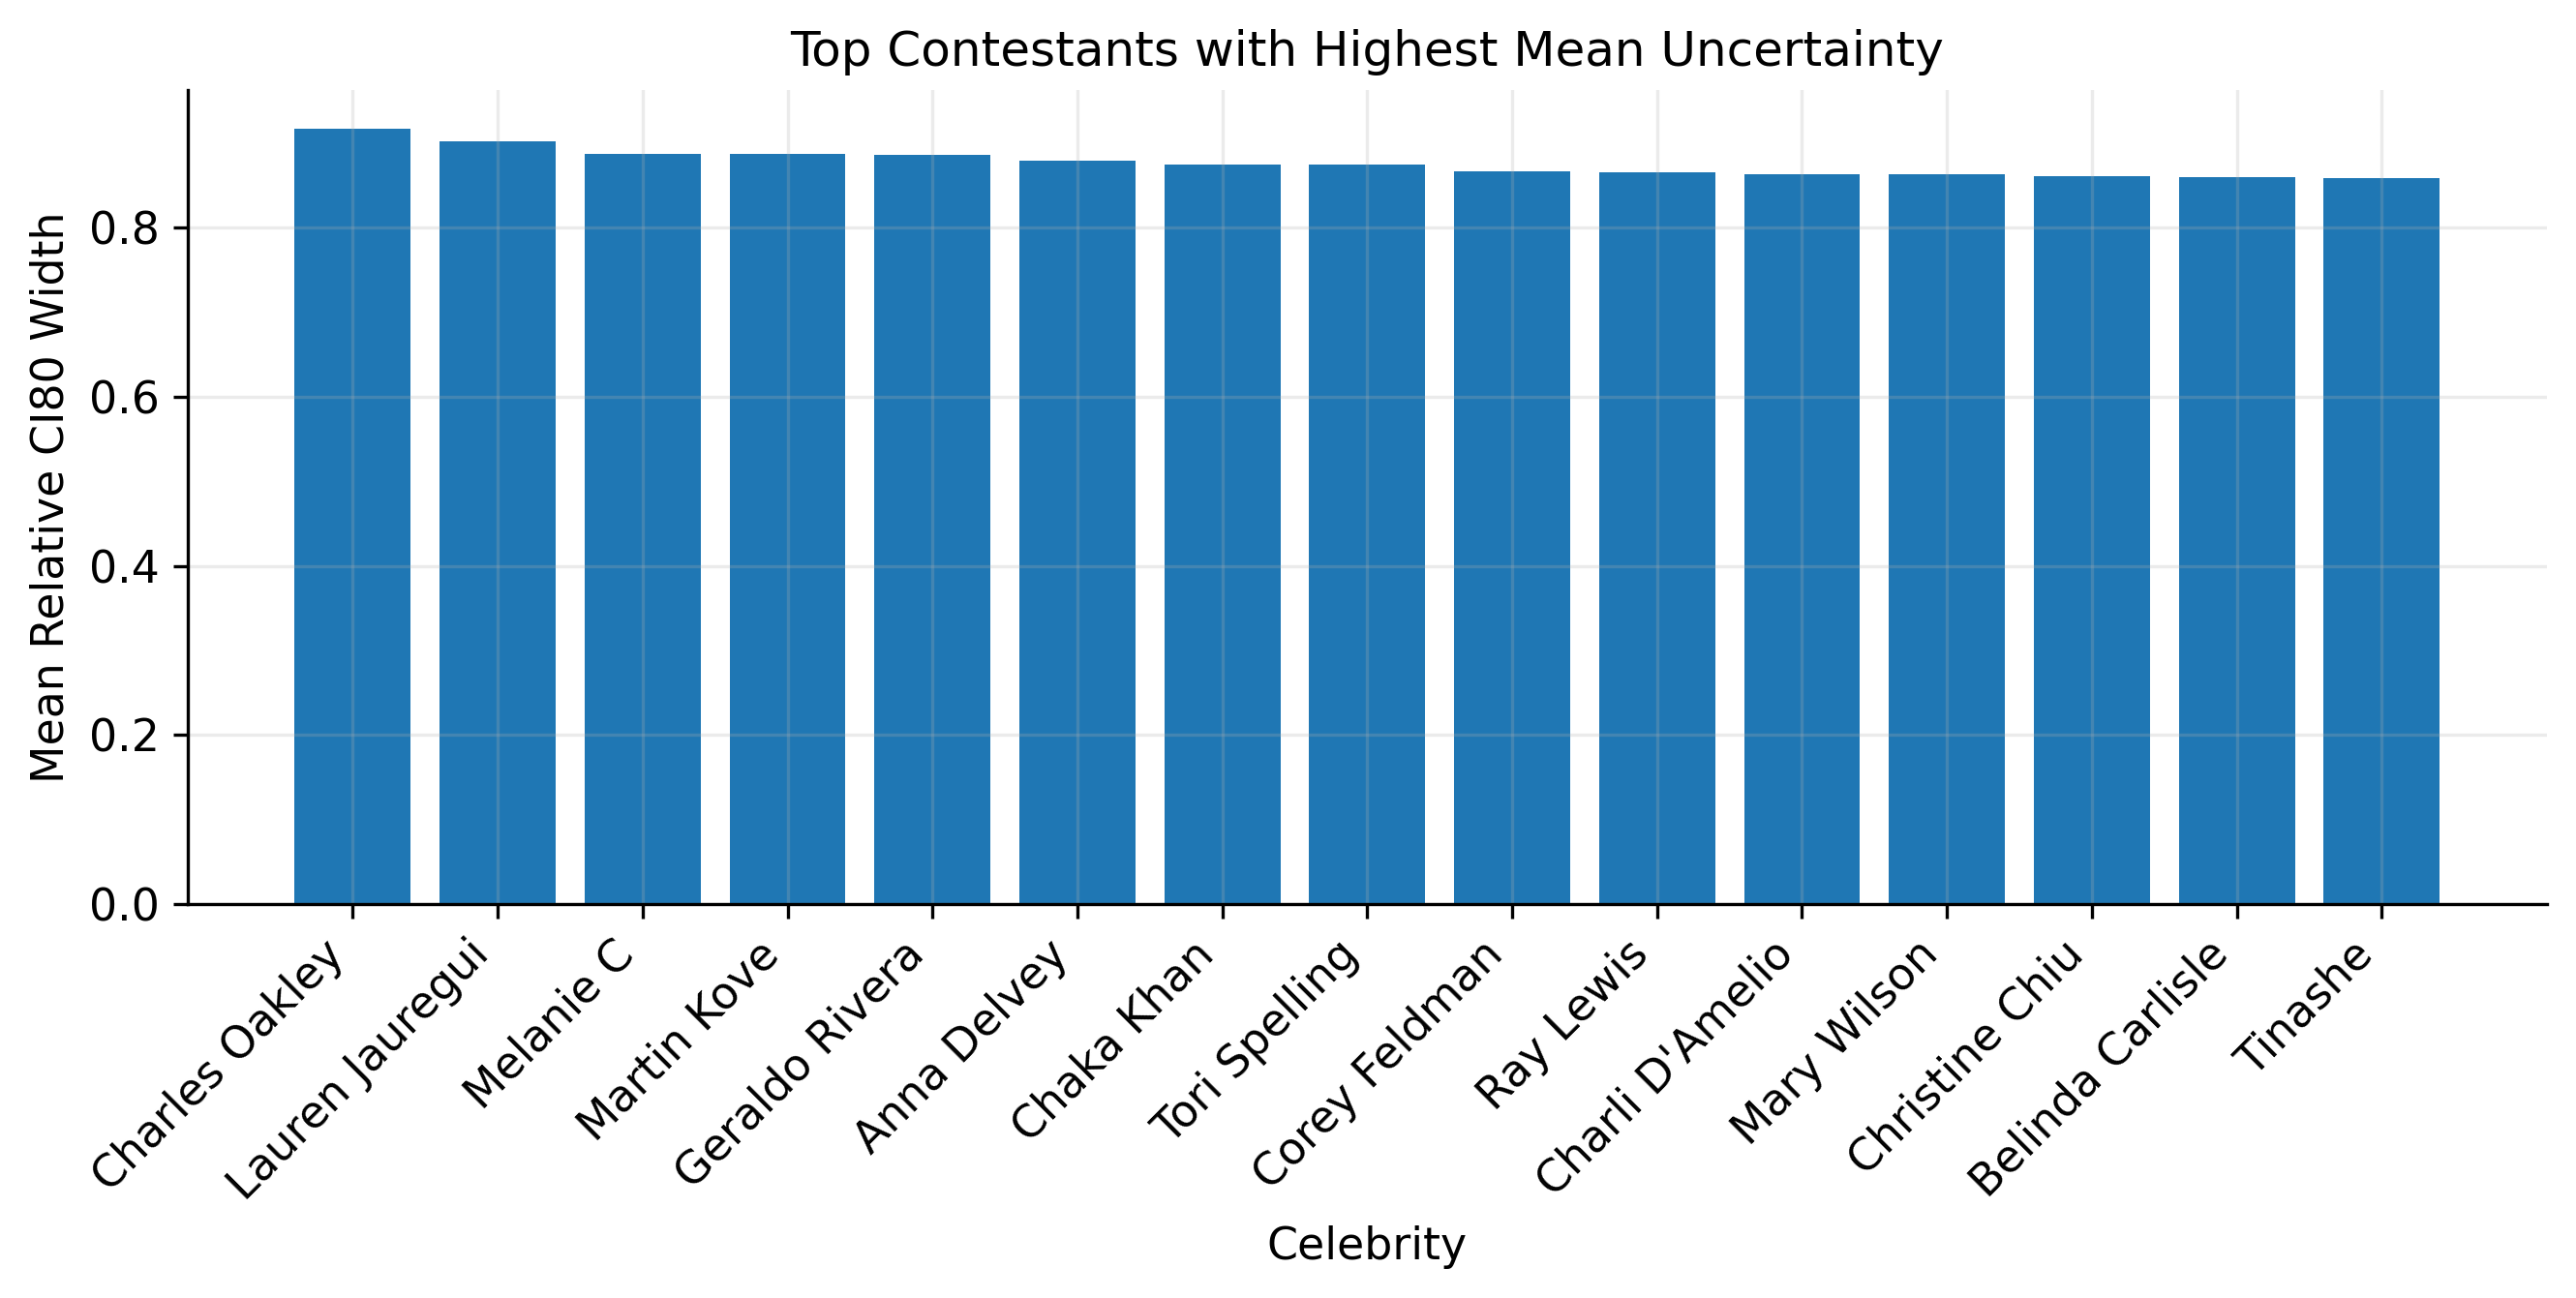

In [254]:
# 8.3 不确定性最高的选手（Top15）——用于说明“不同人并不一致”
topk = 15
plt.figure(figsize=(9.0, 4.6), dpi=300)
plt.bar(cele_unc["celebrity_name"].head(topk), cele_unc["rel_ci80_mean"].head(topk))
plt.title("Top Contestants with Highest Mean Uncertainty")
plt.xlabel("Celebrity")
plt.ylabel("Mean Relative CI80 Width")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
#不同选手间的不确定性存在显著差异，处于中下游位置的选手往往表现出更高预测波动性。


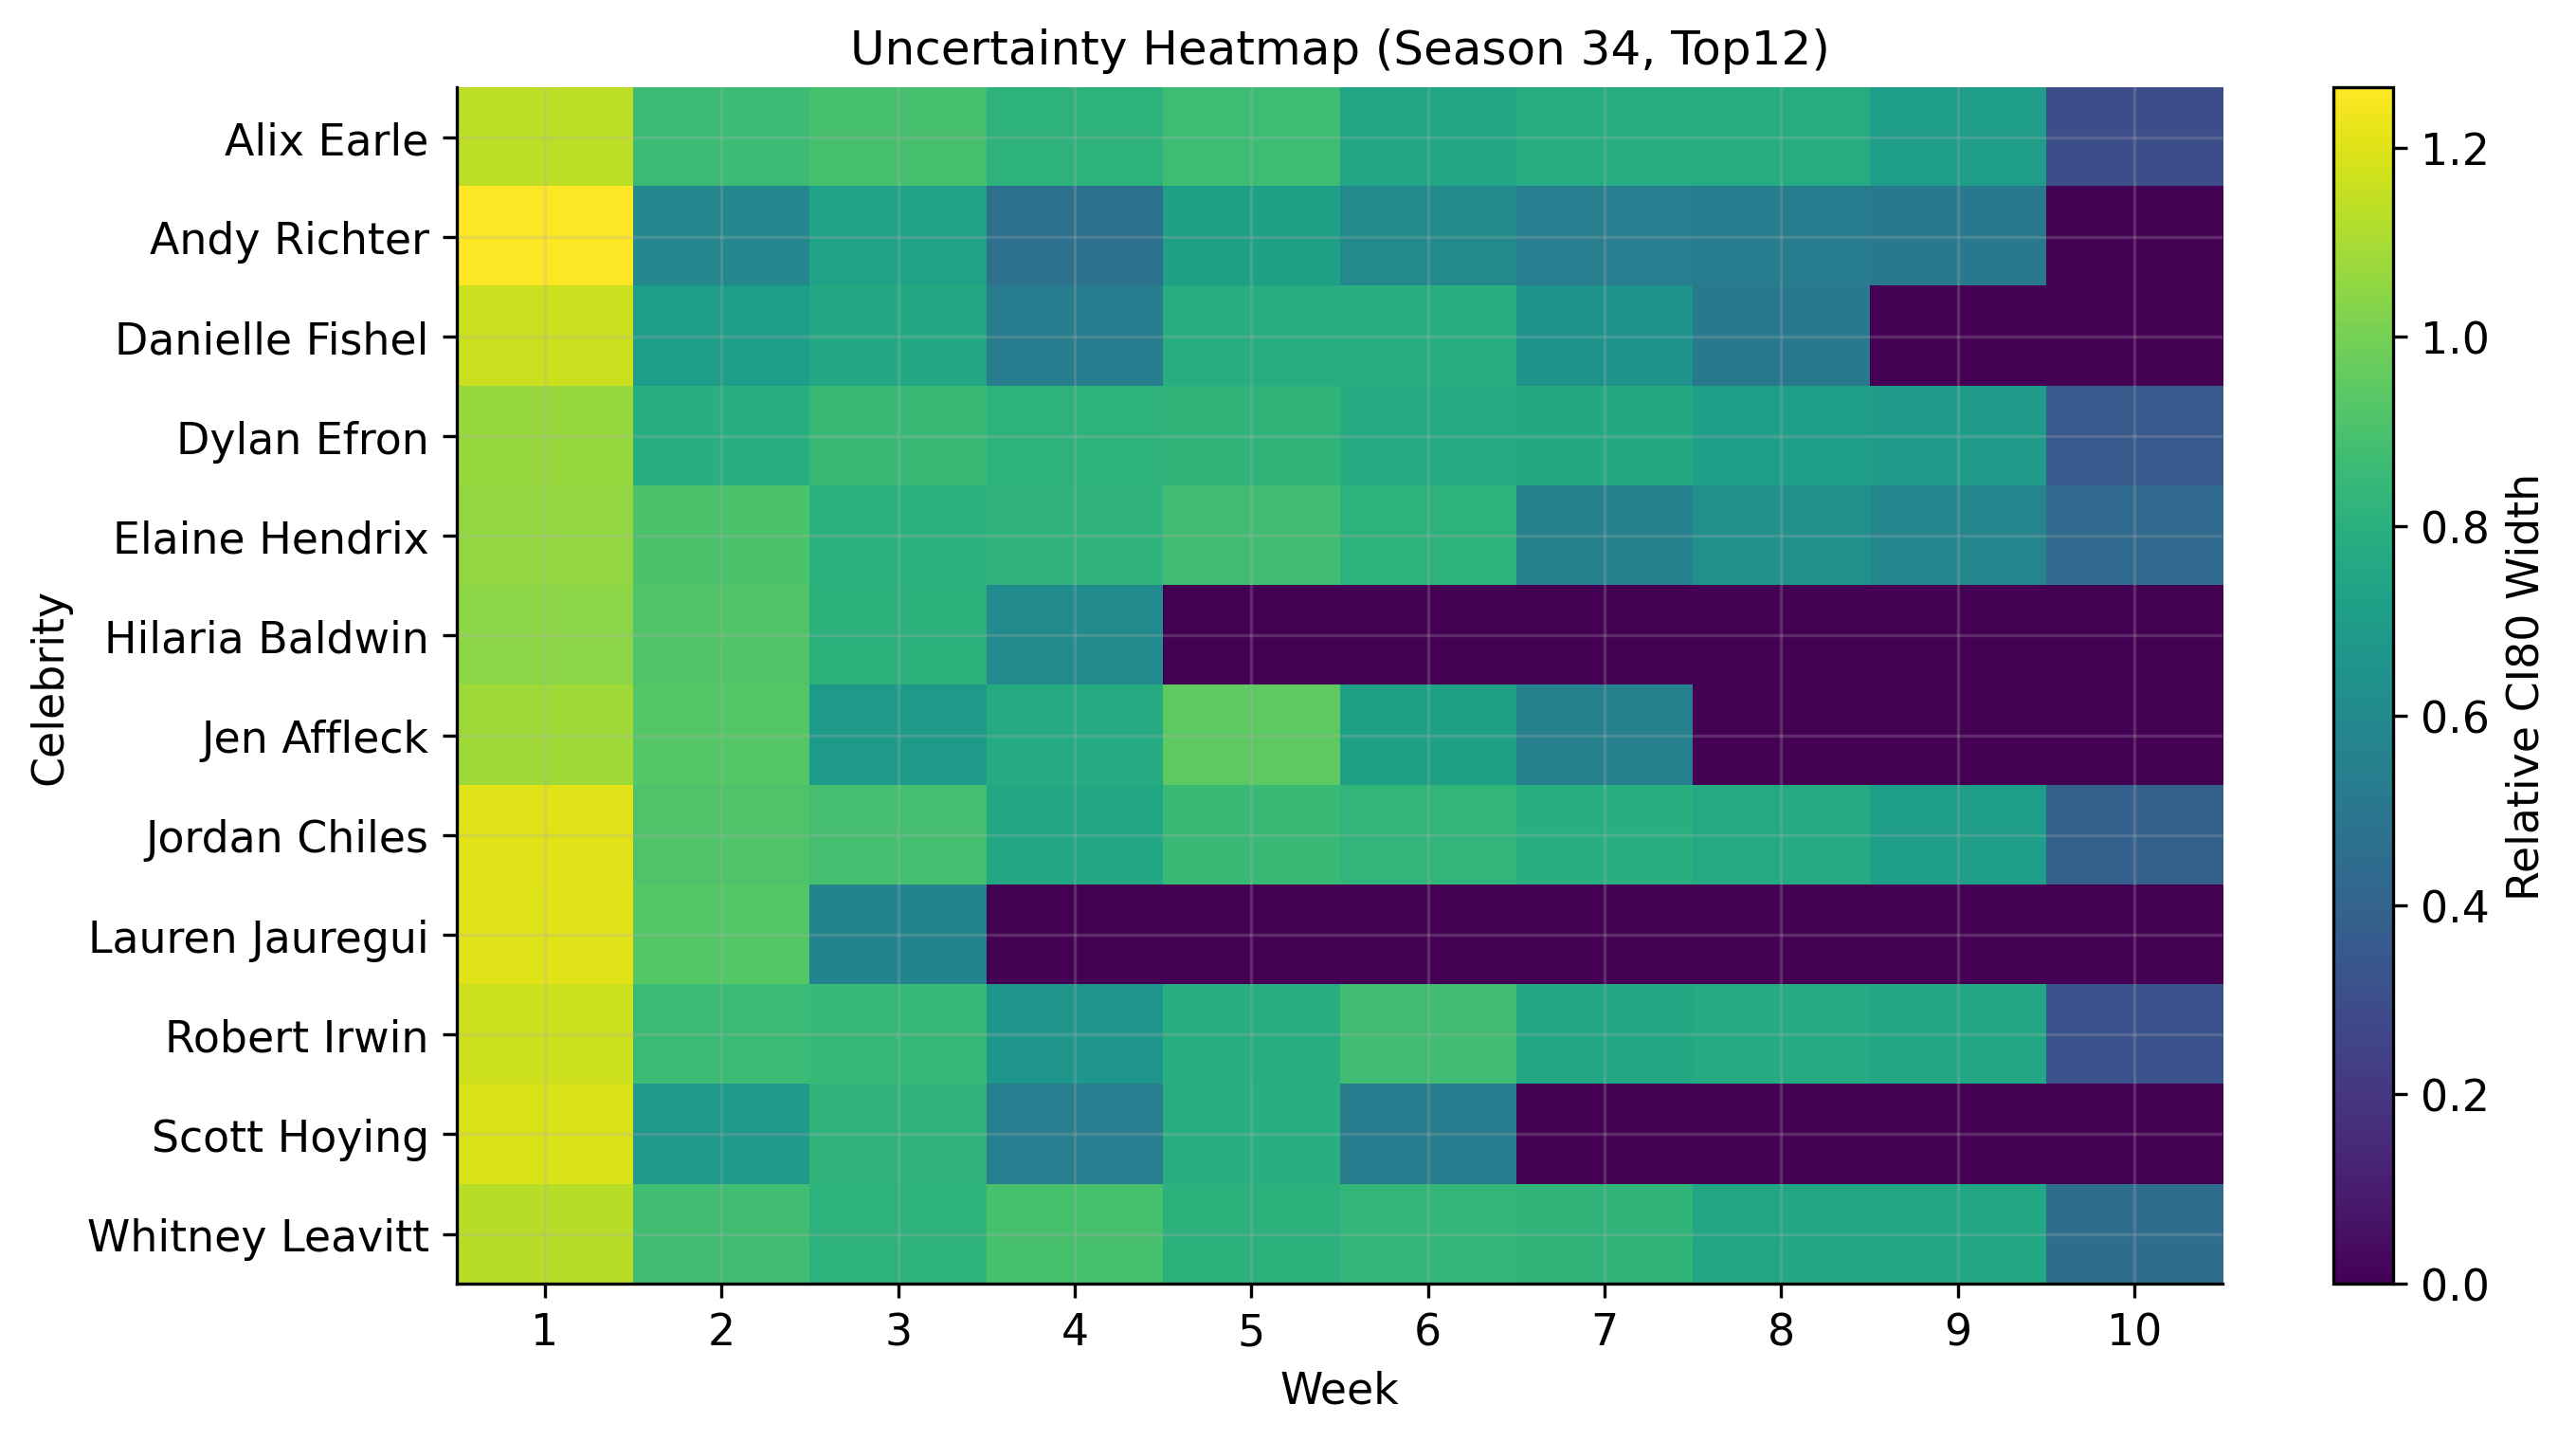

In [255]:
# 8.4 示例赛季：Top12 选手的“不确定性热力图”（用 rel_ci80）
ex_df_u = unc_df[unc_df["season"] == example_season_u].copy()

# 取示例赛季总票数Top12（用中位数总票数更稳健）
top12_u = (
    ex_df_u.groupby("celebrity_name")["votes_q50"].sum()
    .sort_values(ascending=False).head(12).index.tolist()
)

heat_u = ex_df_u[ex_df_u["celebrity_name"].isin(top12_u)].pivot_table(
    index="celebrity_name", columns="week", values="rel_ci80", aggfunc="mean"
).fillna(0)

plt.figure(figsize=(9.6, 5.2), dpi=300)
plt.imshow(heat_u.values, aspect="auto")
plt.title(f"Uncertainty Heatmap (Season {example_season_u}, Top12)")
plt.xlabel("Week")
plt.ylabel("Celebrity")
plt.xticks(ticks=np.arange(heat_u.shape[1]), labels=heat_u.columns.tolist())
plt.yticks(ticks=np.arange(heat_u.shape[0]), labels=heat_u.index.tolist())
cbar = plt.colorbar()
cbar.set_label("Relative CI80 Width")  # 图例/标注英文
plt.tight_layout()
plt.show()
#不确定性热力图显示，在被淘汰前数周，多数选手的不确定性明显上升，表明模型能够捕捉到淘汰风险累积过程。

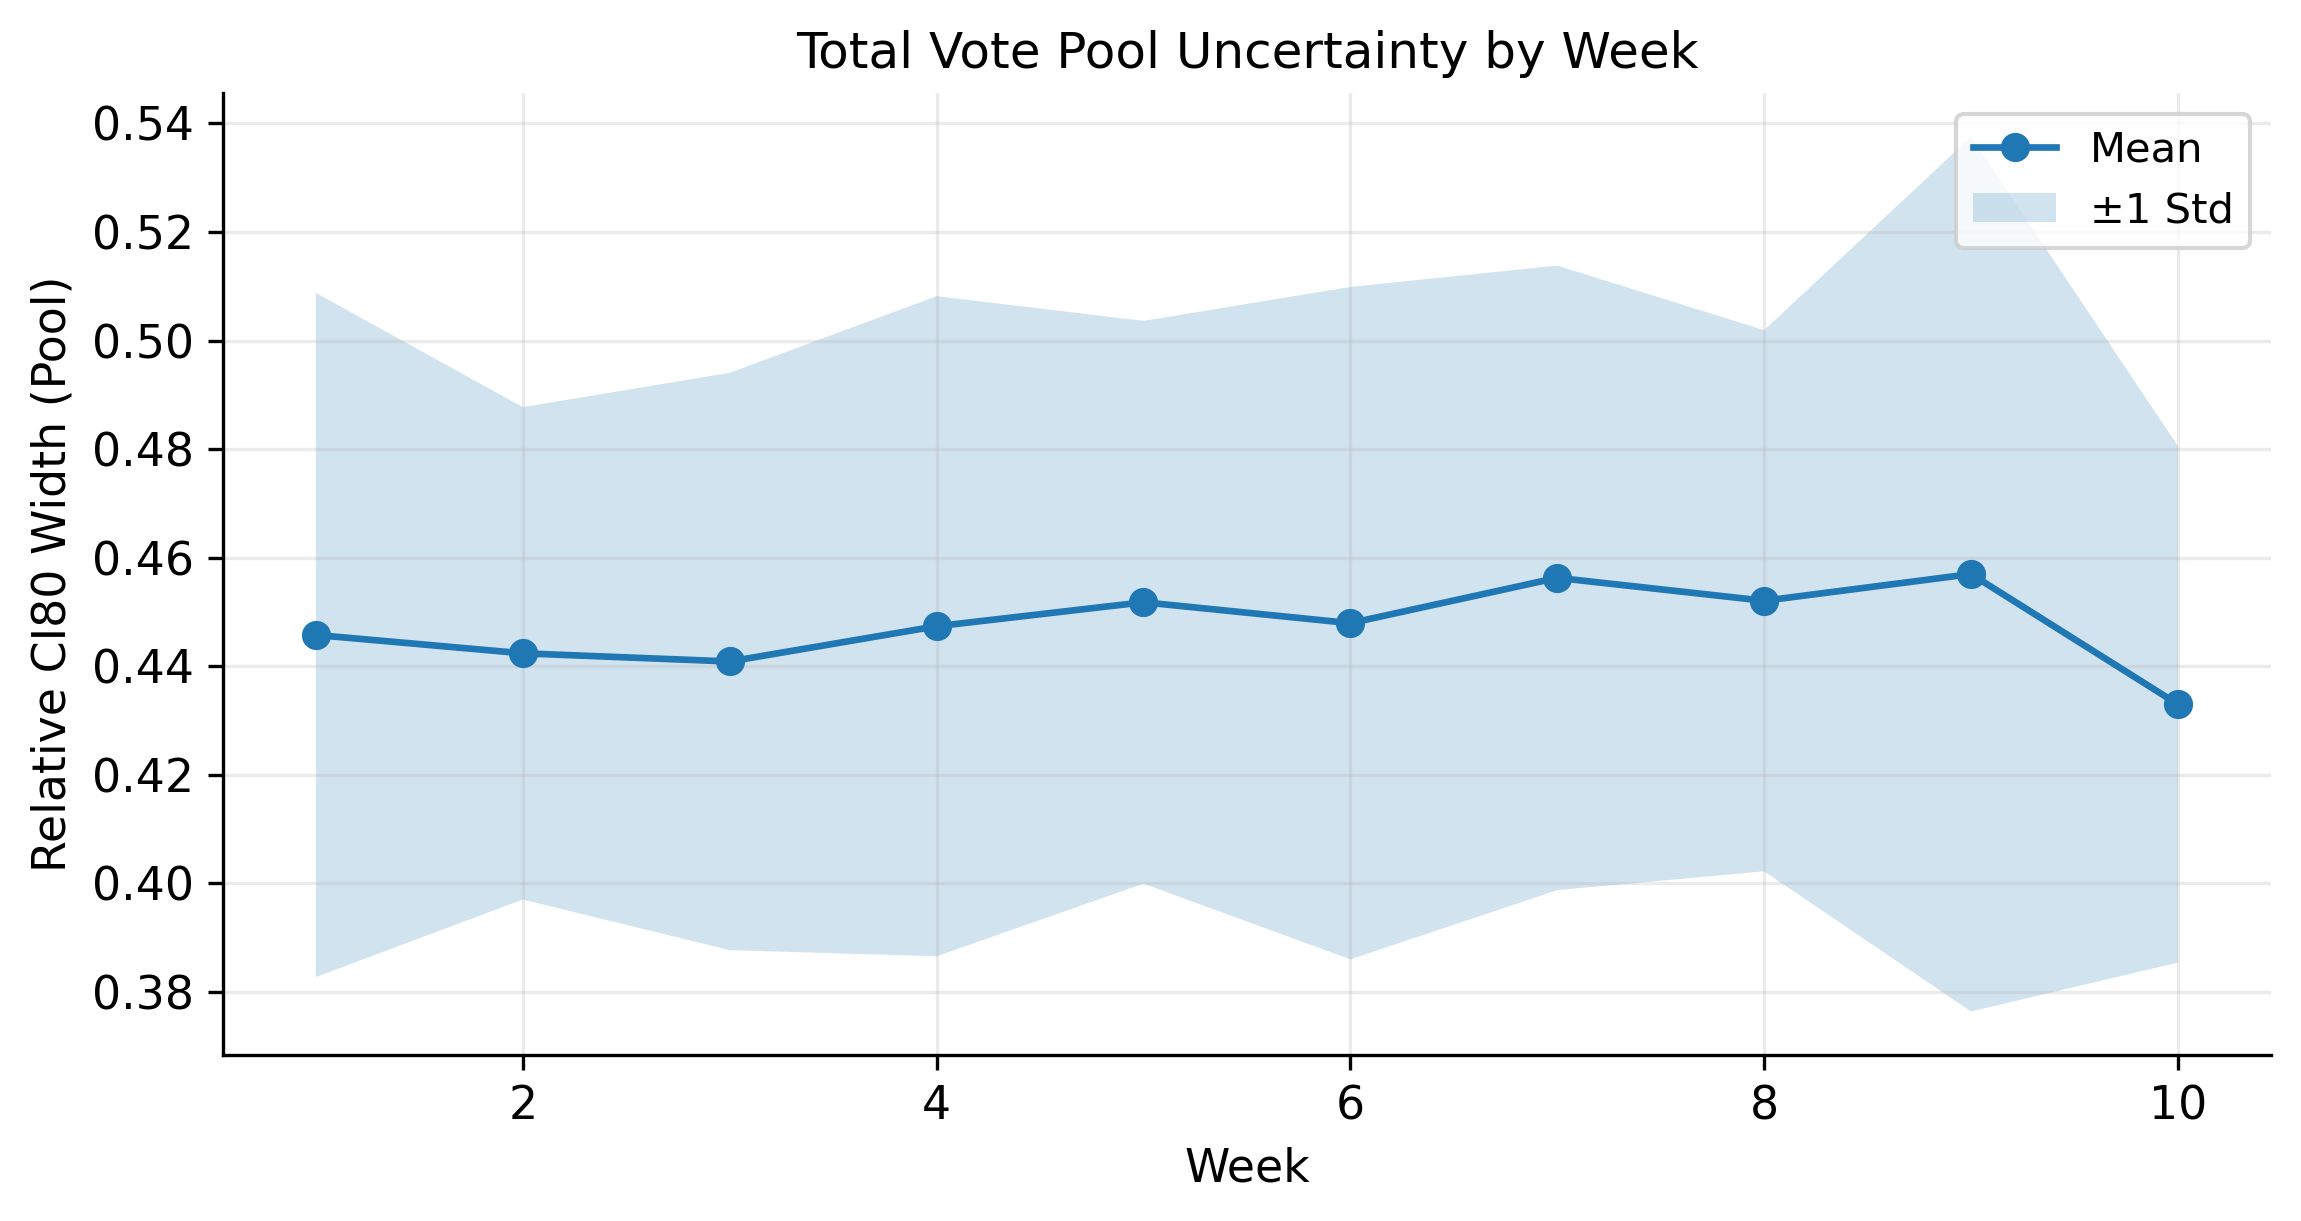

In [256]:
# 8.5 票池不确定性：rel_ci80 随周变化（跨赛季平均）
pool_week = (
    pool_out.assign(week=pool_out["week"].astype(int))
    .groupby("week", as_index=False)
    .agg(pool_rel_ci80_mean=("pool_rel_ci80", "mean"), pool_rel_ci80_std=("pool_rel_ci80", "std"))
    .sort_values("week")
)

plt.figure(figsize=(7.8, 4.2), dpi=300)
plt.plot(pool_week["week"], pool_week["pool_rel_ci80_mean"], marker="o", label="Mean")
plt.fill_between(
    pool_week["week"],
    pool_week["pool_rel_ci80_mean"] - pool_week["pool_rel_ci80_std"],
    pool_week["pool_rel_ci80_mean"] + pool_week["pool_rel_ci80_std"],
    alpha=0.20,
    label="±1 Std"
)
plt.title("Total Vote Pool Uncertainty by Week")
plt.xlabel("Week")
plt.ylabel("Relative CI80 Width (Pool)")
plt.legend()
plt.tight_layout()
plt.show()
#果表明，总投票规模在部分关键周次存在显著波动，反映出观众参与度的阶段性变化。

In [257]:

# ------------------------------------------------------------
# 9) 输出核心结果表（供后续问题使用）
# ------------------------------------------------------------
unc_result_cols = [
    "season","week","celebrity_name",
    "vote_share_hat","total_votes_hat","votes_hat",
    "votes_q10","votes_q50","votes_q90",
    "ci80_width","rel_ci80","cv_votes",
    "judge_total","p_survive_next"
]
unc_result_df = unc_df[unc_result_cols].copy().sort_values(["season","week","votes_q50"], ascending=[True,True,False])

print("\n[Step 3-9] 不确定性主表 unc_result_df 预览：")
unc_result_df.head(15)



[Step 3-9] 不确定性主表 unc_result_df 预览：


,season,week,celebrity_name,vote_share_hat,total_votes_hat,votes_hat,votes_q10,votes_q50,votes_q90,ci80_width,rel_ci80,cv_votes,judge_total,p_survive_next
5,1,1,Trista Sutter,0.168619,800000.0,134895.077126,68745.320061,132555.159373,209220.848662,140475.528601,1.059751,0.389176,18.0,NaN
0,1,1,Evander Holyfield,0.170330,800000.0,136264.038795,71222.974351,130243.715369,209655.068305,138432.093954,1.062870,0.404280,18.0,NaN
3,1,1,Kelly Monaco,0.168692,800000.0,134953.737989,71471.356949,129370.701777,208415.311137,136943.954188,1.058539,0.408106,13.0,NaN
1,1,1,Joey McIntyre,0.167688,800000.0,134150.346467,69752.241945,127095.068685,204393.101645,134640.859700,1.059371,0.399514,20.0,NaN
2,1,1,John O'Hurley,0.162301,800000.0,129840.735706,72690.774296,123541.055770,192271.366803,119580.592507,0.967942,0.390734,20.0,NaN
4,1,1,Rachel Hunter,0.162370,800000.0,129896.063918,71534.368426,122764.956556,195269.381917,123735.013491,1.007902,0.391690,20.0,NaN
6,1,2,Evander Holyfield,0.203224,920000.0,186966.341228,152386.857459,183271.876684,226336.599883,73949.742424,0.403497,0.159475,14.0,NaN
9,1,2,Kelly Monaco,0.189001,920000.0,173881.340960,139039.098791,168382.108862,215278.782841,76239.684050,0.452778,0.187175,17.0,NaN
7,1,2,Joey McIntyre,0.172209,920000.0,158432.708549,122438.597008,151275.968325,203816.963717,81378.366710,0.537946,0.211101,21.0,NaN
10,1,2,Rachel Hunter,0.160854,920000.0,147985.899616,107690.156053,143184.977011,196958.744755,89268.588702,0.623449,0.242104,24.0,NaN
